## 1 · Environment

In [1]:
import platform, subprocess, shutil, os, sys

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("CPU count   :", os.cpu_count())

# RAM
try:
    with open("/proc/meminfo") as f:
        mem = f.readline().split()
    print("System RAM  :", round(int(mem[1]) / 1024 / 1024, 1), "GB")
except Exception:
    print("System RAM  : (unavailable)")

# Platform detection (changes how files are saved and downloaded later)
IS_KAGGLE = os.path.exists("/kaggle/working")
IS_COLAB  = os.path.exists("/content") and not IS_KAGGLE
PLATFORM  = "Kaggle" if IS_KAGGLE else ("Colab" if IS_COLAB else "local/other")
print("Platform    :", PLATFORM)

# GPU
if shutil.which("nvidia-smi"):
    try:
        out = subprocess.run(
            ["nvidia-smi",
             "--query-gpu=name,memory.total,memory.free,driver_version",
             "--format=csv,noheader"],
            capture_output=True, text=True, timeout=30)
        print("GPU         :", out.stdout.strip() or "(query failed)")
    except Exception as e:
        print("GPU         : nvidia-smi error:", e)
else:
    print("GPU         : NONE DETECTED (CPU-only -> the 30B model will be very slow)")

if IS_KAGGLE:
    print("""
KAGGLE CHECKLIST
  1. Accelerator must be 'GPU T4 x2'  (2 x 16 GB = 32 GB, enough for the 30B).
     Settings -> Accelerator -> GPU T4 x2
  2. Internet must be ON, or Ollama and the datasets cannot download.
     Settings -> Internet -> On
  3. Session limit is ~9 hours and files in /kaggle/working are LOST when the
     session ends unless you press 'Save Version'. The LAST cell packages
     everything into one zip - download it before you finish.""")

Python      : 3.12.13
Platform    : Linux-6.12.90+-x86_64-with-glibc2.35
CPU count   : 4
System RAM  : 31.3 GB
Platform    : Kaggle
GPU         : Tesla T4, 15360 MiB, 14912 MiB, 580.159.04
Tesla T4, 15360 MiB, 14912 MiB, 580.159.04

KAGGLE CHECKLIST
  1. Accelerator must be 'GPU T4 x2'  (2 x 16 GB = 32 GB, enough for the 30B).
     Settings -> Accelerator -> GPU T4 x2
  2. Internet must be ON, or Ollama and the datasets cannot download.
     Settings -> Internet -> On
  3. Session limit is ~9 hours and files in /kaggle/working are LOST when the
     session ends unless you press 'Save Version'. The LAST cell packages
     everything into one zip - download it before you finish.


## 2 · Dependencies

In [2]:
# Install once. Safe to re-run.
import sys, subprocess

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)

pip_install([
    "datasets>=2.16.0",
    "statsmodels>=0.14.0",
    "pandas>=2.0.0",
    "matplotlib>=3.7.0",
    "requests>=2.31.0",
    "tqdm>=4.66.0",
    "nvidia-ml-py",        # NVML: GPU power and energy
])
print("Dependencies installed.")

Dependencies installed.


## 3 · Configuration — the only cell you should need to edit

In [3]:
import random, os

# ---- Model -----------------------------------------------------------------
MODEL_NAME       = "qwen3-coder:30b"          # ~18 GB at Q4: needs GPU T4 x2
ALT_MODELS       = ["qwen2.5-coder:7b", "qwen2.5-coder:3b"]   # single-GPU fallbacks
SUPERVISOR_MODEL = None     # None = the code model reviews its own work (self-critique)

if SUPERVISOR_MODEL is not None and not isinstance(SUPERVISOR_MODEL, str):
    raise ValueError("SUPERVISOR_MODEL must be a model name string or None.")

# ---- Experiment ------------------------------------------------------------
M1_BENCHMARKS = [("mbpp", "plus"), ("humaneval", "plus")]   # MBPP+ and HumanEval+
M1_N_PROBLEMS = 20          # questions per benchmark; None = full benchmark
                            # n >= 45 is needed before McNemar has any power
SEED          = 42
MBPP_PLUS_USE_EXTENDED_TESTS = True   # grade MBPP+ with the EvalPlus suite, not 3 asserts

# ---- Repair loop -----------------------------------------------------------
TEMPERATURE               = 0.1
MAX_RETRIES               = 3       # max supervisor -> repair rounds per question
USE_SIGNATURE_HINT        = True    # show an example call so arity/order is not guessed
FEEDBACK_MODE             = "structured"   # "structured" = failing test + got/expected
EARLY_STOP_NO_PROGRESS    = True    # stop when a repair adds no passing tests
USE_TEST_AGENT            = False   # extra LLM-written tests (off: added cost, no repairs)
COMBINE_SUPERVISOR_REPAIR = False   # True = diagnosis folded into the repair call

# ---- Generation / execution ------------------------------------------------
NUM_PREDICT     = 512
NUM_CTX         = 4096
KEEP_ALIVE      = "24h"   # never unload the 30B mid-run: a reload lands in the GPU budget
TIMEOUT_SECONDS = 15      # the plus suites run many assertions per question
M1_TIMEOUT_S    = TIMEOUT_SECONDS

# ---- Output ----------------------------------------------------------------
ON_KAGGLE     = os.path.exists("/kaggle/working")
BASE_DIR      = "/kaggle/working" if ON_KAGGLE else "."
M1_OUTPUT_DIR = os.path.join(BASE_DIR, "outputs_milestone1")
OUTPUT_DIR    = M1_OUTPUT_DIR          # the Ollama log lands here too
os.makedirs(M1_OUTPUT_DIR, exist_ok=True)

random.seed(SEED)

EXPERIMENT_CONFIG = {
    "model_name": MODEL_NAME, "supervisor_model": SUPERVISOR_MODEL,
    "benchmarks": M1_BENCHMARKS, "n_problems": M1_N_PROBLEMS, "seed": SEED,
    "temperature": TEMPERATURE, "max_retries": MAX_RETRIES,
    "use_signature_hint": USE_SIGNATURE_HINT, "feedback_mode": FEEDBACK_MODE,
    "early_stop_no_progress": EARLY_STOP_NO_PROGRESS, "use_test_agent": USE_TEST_AGENT,
    "combine_supervisor_repair": COMBINE_SUPERVISOR_REPAIR,
    "num_predict": NUM_PREDICT, "num_ctx": NUM_CTX, "timeout_seconds": TIMEOUT_SECONDS,
    "mbpp_plus_extended_tests": MBPP_PLUS_USE_EXTENDED_TESTS,
}
print("Results will be written to:", M1_OUTPUT_DIR)
for k, v in EXPERIMENT_CONFIG.items():
    print("  %-26s %s" % (k, v))

Results will be written to: /kaggle/working/outputs_milestone1
  model_name                 qwen3-coder:30b
  supervisor_model           None
  benchmarks                 [('mbpp', 'plus'), ('humaneval', 'plus')]
  n_problems                 20
  seed                       42
  temperature                0.1
  max_retries                3
  use_signature_hint         True
  feedback_mode              structured
  early_stop_no_progress     True
  use_test_agent             False
  combine_supervisor_repair  False
  num_predict                512
  num_ctx                    4096
  timeout_seconds            15
  mbpp_plus_extended_tests   True


## 4 · Kaggle preflight
Checks internet, both GPUs, and keeps the model weights out of the 20 GB output quota.

In [4]:
import os, shutil, subprocess

if ON_KAGGLE:
    print("Platform: KAGGLE\n")

    # --- internet (required for the model pull and the dataset) -------------
    net_ok = False
    try:
        import requests as _rq
        net_ok = _rq.get("https://huggingface.co", timeout=8).status_code < 500
    except Exception:
        net_ok = False
    print("  Internet enabled : %s" % ("YES" if net_ok else "NO"))
    if not net_ok:
        print("    -> Turn Internet ON in the right-hand Settings panel, then re-run.")

    # --- GPUs (30B needs two T4s) ------------------------------------------
    n_gpu, names = 0, ""
    if shutil.which("nvidia-smi"):
        out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                              "--format=csv,noheader"],
                             capture_output=True, text=True)
        names = out.stdout.strip()
        n_gpu = len([l for l in names.splitlines() if l.strip()])
    print("  GPUs detected    : %d" % n_gpu)
    for l in names.splitlines():
        print("     %s" % l.strip())
    if n_gpu < 2 and "30b" in MODEL_NAME.lower():
        print("    -> WARNING: %s needs ~18GB. With one GPU it will not fit."
              % MODEL_NAME)
        print("       Either set Accelerator = 'GPU T4 x2', or change MODEL_NAME")
        print("       to 'qwen2.5-coder:7b' in the configuration cell.")

    # --- keep the 18GB model OUT of /kaggle/working ------------------------
    # Anything under /kaggle/working counts toward the 20GB output limit and is
    # copied on 'Save Version'. Model weights belong in scratch space.
    scratch = "/kaggle/temp/ollama" if os.path.exists("/kaggle/temp") else "/root/.ollama"
    os.makedirs(scratch, exist_ok=True)
    os.environ["OLLAMA_MODELS"] = scratch
    print("  Model store      : %s  (scratch - not saved to Output)" % scratch)

    # --- disk headroom -----------------------------------------------------
    for path in ["/kaggle/working", scratch]:
        try:
            st = os.statvfs(path)
            print("  Free on %-16s %.1f GB" % (path + ":", st.f_bavail * st.f_frsize / 1e9))
        except Exception:
            pass
    print("\n  Session limit is ~9 hours. Check the pilot's runtime estimate")
    print("  (Section 19) before enabling the main experiment.")
    print("  Outputs will be written under /kaggle/working so they are downloadable.")
else:
    print("Not on Kaggle - preflight skipped.")

Platform: KAGGLE

  Internet enabled : YES
  GPUs detected    : 2
     Tesla T4, 15360 MiB
     Tesla T4, 15360 MiB
  Model store      : /root/.ollama  (scratch - not saved to Output)
  Free on /kaggle/working: 20.9 GB
  Free on /root/.ollama:   1100.2 GB

  Session limit is ~9 hours. Check the pilot's runtime estimate
  (Section 19) before enabling the main experiment.
  Outputs will be written under /kaggle/working so they are downloadable.


## 5 · Ollama server
Installs and starts Ollama. `OLLAMA_NUM_PARALLEL=1` is set on purpose: batched requests would
share one GPU window and make per-call energy unattributable.

In [5]:
import subprocess, shutil, time, os, requests

OLLAMA_HOST = "http://127.0.0.1:11434"

def ollama_up():
    try:
        return requests.get(OLLAMA_HOST + "/api/tags", timeout=3).status_code == 200
    except Exception:
        return False

def _sh(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True)

if not shutil.which("ollama"):
    # 1) Ollama's installer requires zstd for extraction -> install it first.
    if not shutil.which("zstd"):
        print("Installing zstd ...")
        r = _sh("apt-get update -qq && apt-get install -y -qq zstd")
        if r.returncode != 0:                       # retry with sudo if not root
            r = _sh("sudo apt-get update -qq && sudo apt-get install -y -qq zstd")
        if not shutil.which("zstd"):
            raise RuntimeError("Could not install zstd:\n" + (r.stderr or "")[-1500:])

    # 2) now run the Ollama installer
    print("Installing Ollama ...")
    r = _sh("curl -fsSL https://ollama.com/install.sh | sh")
    print((r.stdout or "")[-600:]); print((r.stderr or "")[-600:])
else:
    print("Ollama already installed:", shutil.which("ollama"))

# resolve the binary (installer puts it in /usr/local/bin)
OLLAMA_BIN = shutil.which("ollama") or "/usr/local/bin/ollama"
if not os.path.exists(OLLAMA_BIN):
    raise RuntimeError("Ollama still not installed. Check the installer output above "
                       "and that this notebook has Internet enabled.")
print("Ollama binary:", OLLAMA_BIN)

if not ollama_up():
    print("Starting Ollama server ...")
    os.environ.setdefault("OLLAMA_HOST", "127.0.0.1:11434")
    os.environ["OLLAMA_NUM_PARALLEL"] = "1"       # one call at a time -> attributable energy
    os.environ["OLLAMA_MAX_LOADED_MODELS"] = "1"  # nothing else resident in VRAM
    os.environ["OLLAMA_KEEP_ALIVE"] = KEEP_ALIVE
    _log = open(os.path.join(OUTPUT_DIR, "ollama_serve.log"), "w")
    subprocess.Popen([OLLAMA_BIN, "serve"], stdout=_log, stderr=_log)
    for _ in range(60):
        if ollama_up():
            break
        time.sleep(1)

print("Ollama server reachable:", ollama_up())
if not ollama_up():
    raise RuntimeError("Ollama server did not come up. Check outputs/ollama_serve.log "
                       "and that this environment allows background processes.")

Installing zstd ...
Installing Ollama ...

####     97.0%
######################################################################    98.2%
#######################################################################   99.3%
#######################################################################   99.7%
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

Ollama binary: /usr/local/bin/ollama
Starting Ollama server ...
Ollama server reachable: True


## 6 · Model download and verification

In [6]:
import subprocess, requests, json, time

def list_local_models():
    try:
        r = requests.get(OLLAMA_HOST + "/api/tags", timeout=10)
        return [m["name"] for m in r.json().get("models", [])]
    except Exception:
        return []

def ensure_model(name):
    if not isinstance(name, str) or not name.strip():
        raise ValueError("ensure_model() needs a model name string, got %r" % (name,))
    local = list_local_models()
    if name in local or (name + ":latest") in local:
        print("Model present:", name)
        return True
    print("Pulling model '%s' (this can take a while / large download) ..." % name)
    p = subprocess.run(["ollama", "pull", name], capture_output=True, text=True)
    if p.returncode != 0:
        print("Pull FAILED:\n", p.stderr[-2000:])
        return False
    return name in list_local_models()

ok = ensure_model(MODEL_NAME)
if not ok:
    print("\n[!] Could not obtain '%s'." % MODEL_NAME)
    print("    Available locally:", list_local_models())
    print("    Consider setting MODEL_NAME to one of:", ALT_MODELS)
    raise RuntimeError("Model '%s' unavailable. Edit MODEL_NAME in the config cell." % MODEL_NAME)

# Confirm the model actually generates
def _quick_probe(name):
    t0 = time.time()
    r = requests.post(OLLAMA_HOST + "/api/chat", timeout=300, json={
        "model": name, "stream": False,
        "messages": [{"role": "user", "content": "Reply with the single word: OK"}],
        "options": {"temperature": 0.0, "num_predict": 8},
    })
    return r.json()["message"]["content"].strip(), time.time() - t0

resp, dt = _quick_probe(MODEL_NAME)
print("Model responded in %.1fs -> %r" % (dt, resp[:60]))

# Optional independent reviewer model
if SUPERVISOR_MODEL and SUPERVISOR_MODEL != MODEL_NAME:
    print("\nSupervisor uses a SEPARATE model:", SUPERVISOR_MODEL)
    if not ensure_model(SUPERVISOR_MODEL):
        raise RuntimeError("Supervisor model %r unavailable." % SUPERVISOR_MODEL)
    r2, d2 = _quick_probe(SUPERVISOR_MODEL)
    print("  responded in %.1fs -> %r" % (d2, r2[:40]))
    print("  NOTE: both models stay resident (keep_alive), so VRAM must hold BOTH.")
    print("        30B (~18GB) + 7B (~5GB) needs ~23GB - fits 2x T4 (32GB).")
else:
    print("Supervisor shares the code model (self-critique).")
print("Model verification: PASSED")

Pulling model 'qwen3-coder:30b' (this can take a while / large download) ...
Model responded in 125.1s -> 'OK'
Supervisor shares the code model (self-critique).
Model verification: PASSED


## 7 · Benchmark helpers
Turns each benchmark's test block into one runnable unit and extracts an example call signature.

In [7]:
import re, random

# HumanEval signatures use typing names; provide them so a missing import is not
# scored as a logic failure (standard in HumanEval harnesses).
HUMANEVAL_SETUP = ("from typing import List, Tuple, Dict, Set, Optional, Any, Union\n"
                   "import math\n")


def extract_entry_point(test_list):
    for t in test_list:
        m = re.search(r'assert\s+([A-Za-z_]\w*)\s*\(', t)
        if m:
            return m.group(1)
        m = re.search(r'([A-Za-z_]\w*)\s*\(', t)
        if m:
            return m.group(1)
    return None


def wrap_composite_test(test_code, entry):
    """Turn a benchmark test BLOCK into one runnable unit.
      1. defines `def check(candidate)`  -> call check(entry)
      2. refers to a bare `candidate`    -> bind candidate = entry first
      3. plain assert statements         -> run as-is
    """
    t = test_code or ""
    if "def check(" in t:
        return "%s\n\ncheck(%s)\n" % (t, entry)
    if "candidate" in t:
        return "candidate = %s\n%s\n" % (entry, t)
    return t


def extract_call_signature(asserts, entry, max_len=160):
    """Hint showing HOW the function is called, taken from the example tests."""
    if not entry:
        return None
    for a in asserts:
        i = a.find(entry + "(")
        if i < 0:
            continue
        j = i + len(entry)
        depth, k = 0, j
        for k in range(j, len(a)):           # balanced-paren scan
            if a[k] == "(":
                depth += 1
            elif a[k] == ")":
                depth -= 1
                if depth == 0:
                    break
        call = a[i:k + 1]
        inner = call[len(entry) + 1:-1]
        depth, n_args = 0, (1 if inner.strip() else 0)
        for ch in inner:
            if ch in "([{":
                depth += 1
            elif ch in ")]}":
                depth -= 1
            elif ch == "," and depth == 0:
                n_args += 1
        if len(call) > max_len:
            call = call[:max_len] + "...)"
        return ("The function is called with %d positional argument(s). "
                "Example call from the tests: %s" % (n_args, call))
    return None


def sample_main_set(problems, n, seed=SEED):
    """Reproducible sample: shuffle once with SEED, take the first n (None = all)."""
    rr = random.Random(seed)
    order = list(range(len(problems)))
    rr.shuffle(order)
    n_eff = len(problems) if n is None else min(n, len(problems))
    return [problems[i] for i in order[:n_eff]]

print("Benchmark helpers ready.")

Benchmark helpers ready.


## 8 · Execution sandbox
Every candidate runs in a separate process with a timeout and a memory cap.

In [8]:
import tempfile, subprocess, os, json, shutil, sys

# Runner executed inside the subprocess. Reads a payload file, exec's the
# solution once, then runs each test in isolation and reports JSON.
RUNNER_SRC = """
import json, sys, os, ast, traceback

def _describe(test_src, ns):
    # For 'assert <left> <op> <right>' return the actual vs expected values.
    try:
        node = ast.parse(test_src.strip()).body[0]
        if isinstance(node, ast.Assert) and isinstance(node.test, ast.Compare) \
           and len(node.test.ops) == 1:
            left = ast.Expression(node.test.left)
            right = ast.Expression(node.test.comparators[0])
            lval = eval(compile(left, '<l>', 'eval'), ns)
            rval = eval(compile(right, '<r>', 'eval'), ns)
            op = type(node.test.ops[0]).__name__
            return 'got %r, expected (%s) %r' % (lval, op, rval)
    except Exception:
        return None
    return None

def main():
    d = sys.argv[1]
    with open(os.path.join(d, 'payload.json')) as f:
        payload = json.load(f)
    code  = payload['code']
    setup = payload.get('setup', '')
    tests = payload['tests']
    ns = {}
    out = {'import_ok': True, 'fatal': None, 'results': []}
    try:
        if setup:
            exec(compile(setup, '<setup>', 'exec'), ns)
        exec(compile(code, '<solution>', 'exec'), ns)
    except Exception:
        out['import_ok'] = False
        out['fatal'] = traceback.format_exc()
        print(json.dumps(out)); return
    for i, t in enumerate(tests):
        r = {'index': i, 'passed': False, 'error': None, 'test': t[:200], 'detail': None}
        try:
            exec(compile(t, '<test%d>' % i, 'exec'), ns)
            r['passed'] = True
        except AssertionError:
            r['error'] = traceback.format_exc()
            r['detail'] = _describe(t, ns)
        except Exception:
            r['error'] = traceback.format_exc()
        out['results'].append(r)
    print(json.dumps(out))
if __name__ == '__main__':
    main()
"""

def _rlimit_preexec(timeout):
    def _apply():
        try:
            import resource
            resource.setrlimit(resource.RLIMIT_CPU, (timeout + 1, timeout + 2))
            resource.setrlimit(resource.RLIMIT_AS, (2 * 1024**3, 2 * 1024**3))  # 2 GB
        except Exception:
            pass
    return _apply

def run_in_sandbox(code, tests, setup="", timeout=None):
    if timeout is None:
        timeout = TIMEOUT_SECONDS
    d = tempfile.mkdtemp(prefix="mas_")
    empty = {"timed_out": False, "import_ok": False, "fatal": None,
             "results": [], "n_tests": len(tests), "n_passed": 0,
             "n_failed": len(tests), "stdout": "", "stderr": ""}
    try:
        with open(os.path.join(d, "runner.py"), "w") as f:
            f.write(RUNNER_SRC)
        with open(os.path.join(d, "payload.json"), "w") as f:
            json.dump({"code": code, "setup": setup, "tests": tests}, f)
        kw = dict(capture_output=True, text=True, timeout=timeout, cwd=d)
        if os.name == "posix":
            kw["preexec_fn"] = _rlimit_preexec(timeout)
        try:
            proc = subprocess.run([sys.executable, "runner.py", d], **kw)
        except subprocess.TimeoutExpired:
            r = dict(empty); r["timed_out"] = True; r["fatal"] = "TimeoutExpired"
            r["stderr"] = "Timeout after %ss" % timeout; return r
        parsed = None
        for line in reversed(proc.stdout.strip().splitlines()):
            line = line.strip()
            if line.startswith("{"):
                try:
                    parsed = json.loads(line); break
                except Exception:
                    pass
        if parsed is None:
            r = dict(empty); r["fatal"] = (proc.stderr or "no runner output")[:2000]
            r["stdout"] = proc.stdout; r["stderr"] = proc.stderr; return r
        n_pass = sum(1 for x in parsed["results"] if x["passed"])
        return {"timed_out": False, "import_ok": parsed["import_ok"],
                "fatal": parsed["fatal"], "results": parsed["results"],
                "n_tests": len(tests), "n_passed": n_pass,
                "n_failed": len(tests) - n_pass,
                "stdout": proc.stdout, "stderr": proc.stderr}
    finally:
        shutil.rmtree(d, ignore_errors=True)

def all_passed(res):
    return bool(res["import_ok"]) and res["n_tests"] > 0 and res["n_failed"] == 0

def first_error(res):
    if res.get("timed_out"):
        return "TimeoutExpired: execution exceeded %ss" % TIMEOUT_SECONDS
    if res.get("fatal"):
        return res["fatal"][:1500]
    for x in res.get("results", []):
        if not x["passed"] and x.get("error"):
            # BARE mode: raw traceback only - reproduces the weak original setup
            if globals().get("FEEDBACK_MODE", "structured") == "bare":
                return x["error"][:1500]
            parts = []
            t = x.get("test") or ""
            # only echo short, single-assert tests; composite check() bodies are
            # noise (the traceback already pinpoints the failing line)
            if t and len(t) < 200 and t.count("assert") <= 1:
                parts.append("Failing test: " + t)
            if x.get("detail"):          # e.g. "got 8, expected (Eq) 6"
                parts.append("Observed: " + x["detail"])
            parts.append(x["error"][:1200])
            return "\n".join(parts)[:1800]
    return ""

def classify_failure(res):
    if res.get("timed_out"):
        return "Timeout"
    text = first_error(res)
    if not text:
        return "None"
    if "SyntaxError" in text or "IndentationError" in text:
        return "SyntaxError"
    if "ModuleNotFoundError" in text or "ImportError" in text:
        return "Missing import"
    if "AssertionError" in text:
        return "AssertionError"
    if "TypeError" in text and ("argument" in text or "positional" in text):
        return "Wrong function signature"
    if "NameError" in text:
        return "Wrong function signature"
    if "Error" in text or "Exception" in text:
        return "RuntimeError"
    return "Other"

# self-test the sandbox on trivial code
_t = run_in_sandbox("def add(a,b):\n    return a+b\n", ["assert add(2,3)==5"])
print("Sandbox self-test passed:", all_passed(_t))
_t2 = run_in_sandbox("def add(a,b):\n    return a-b\n", ["assert add(2,3)==5"])
print("Sandbox catches wrong answer:", (not all_passed(_t2)),
      "-> classified as", classify_failure(_t2))

Sandbox self-test passed: True
Sandbox catches wrong answer: True -> classified as AssertionError


## 9 · LLM interface

In [9]:
import requests, time, hashlib

class OllamaLLM:
    def __init__(self, model, temperature=0.1, host=OLLAMA_HOST, use_cache=True,
                 num_predict=NUM_PREDICT, num_ctx=NUM_CTX, keep_alive=KEEP_ALIVE):
        self.model = model
        self.temperature = temperature
        self.host = host
        self.use_cache = use_cache
        self.num_predict = num_predict
        self.num_ctx = num_ctx
        self.keep_alive = keep_alive
        self.cache = {}
        self.actual_calls = 0   # real network calls (cache misses)

    def chat(self, system, user):
        key = hashlib.sha256(
            ("|".join([self.model, str(self.temperature), system, user])).encode()
        ).hexdigest()
        if self.use_cache and key in self.cache:
            return self.cache[key], 0.0, True
        msgs = []
        if system:
            msgs.append({"role": "system", "content": system})
        msgs.append({"role": "user", "content": user})
        t0 = time.time()
        r = requests.post(self.host + "/api/chat", timeout=600, json={
            "model": self.model, "stream": False, "messages": msgs,
            "keep_alive": self.keep_alive,
            "options": {"temperature": self.temperature,
                        "num_predict": self.num_predict,
                        "num_ctx": self.num_ctx},
        })
        dt = time.time() - t0
        r.raise_for_status()
        content = r.json()["message"]["content"]
        self.actual_calls += 1
        if self.use_cache:
            self.cache[key] = content
        return content, dt, False

def extract_code(text):
    import re
    blocks = re.findall(r"```(?:python|py)?\s*\n(.*?)```", text, re.DOTALL)
    if blocks:
        return max(blocks, key=len).strip()
    return text.strip()

def extract_asserts(text, entry):
    import re
    blocks = re.findall(r"```(?:python|py)?\s*\n(.*?)```", text, re.DOTALL)
    body = "\n".join(blocks) if blocks else text
    out = []
    for ln in body.splitlines():
        s = ln.strip()
        if s.startswith("assert") and (entry is None or entry in s):
            out.append(s)
    return out

## 10 · Agents
**Code agent** writes and repairs code · **Test agent** (off by default) · **Supervisor** diagnoses failures.

In [10]:
class CodeGenerationAgent:
    SYS = ("You are an expert Python programmer. Write correct, self-contained "
           "Python. Return ONLY one ```python code block with the required "
           "function (plus any imports it needs). No prose.")

    def __init__(self, llm):
        self.llm = llm

    def generate(self, text, entry, hint=None):
        extra = ("\n%s\nMatch that call signature exactly.\n" % hint) if hint else ""
        prompt = ("Problem:\n%s\n%s\nImplement the function named `%s`.\n"
                  "Return only the function definition (and needed imports) "
                  "in one python code block." % (text, extra, entry))
        raw, dt, cached = self.llm.chat(self.SYS, prompt)
        return extract_code(raw), dt

    def repair(self, text, entry, prev_code, feedback, hint=None):
        prompt = ("Problem:\n%s\n\nYour previous solution FAILED its tests.\n\n"
                  "Previous code:\n```python\n%s\n```\n\n"
                  "Reviewer feedback:\n%s\n\n"
                  "Return a corrected, complete implementation of `%s` in one "
                  "python code block. Fix the specific issue; keep the same "
                  "function name and signature.%s"
                  % (text, prev_code, feedback, entry,
                     ("\n" + hint) if hint else ""))
        raw, dt, cached = self.llm.chat(self.SYS, prompt)
        return extract_code(raw), dt

In [11]:
class TestGenerationAgent:
    SYS = ("You are a meticulous test engineer. Write black-box assert-based "
           "unit tests derived from the PROBLEM statement, not from any given "
           "implementation.")

    def __init__(self, llm):
        self.llm = llm

    def generate(self, text, entry, code):
        prompt = ("Problem:\n%s\n\nFunction under test: `%s`.\n"
                  "Write 3-5 additional `assert` statements (one per line) that "
                  "check correctness based on the problem. Use only `%s`. "
                  "Return them in one python code block."
                  % (text, entry, entry))
        raw, dt, cached = self.llm.chat(self.SYS, prompt)
        tests = extract_asserts(raw, entry)
        return tests[:5], dt

In [12]:
class SupervisorAgent:
    SYS = ("You are a senior code reviewer. Given failing test output, diagnose "
           "the ROOT CAUSE in 2-4 sentences and give one concrete, specific "
           "instruction to fix it. Be precise and short.")

    def __init__(self, llm):
        self.llm = llm

    def review(self, text, code, error_excerpt):
        prompt = ("Problem:\n%s\n\nCode:\n```python\n%s\n```\n\n"
                  "Failing test output:\n%s\n\n"
                  "Give the root cause and a concrete fix instruction."
                  % (text, code, error_excerpt))
        raw, dt, cached = self.llm.chat(self.SYS, prompt)
        return raw.strip(), dt

## 11 · Multi-agent orchestrator
Generate → run tests → (supervisor → repair → run tests) × up to `MAX_RETRIES`.

In [13]:
class MultiAgentOrchestrator:
    def __init__(self, code_agent, test_agent, supervisor, max_retries=3,
                 use_test_agent=True, combine_supervisor_repair=False,
                 early_stop_no_progress=True):
        self.code_agent = code_agent
        self.test_agent = test_agent
        self.supervisor = supervisor
        self.max_retries = max_retries
        self.use_test_agent = use_test_agent
        self.combine = combine_supervisor_repair
        self.early_stop = early_stop_no_progress

    def solve(self, p):
        import time
        text, entry = p["text"], p["entry_point"]
        mbpp_tests, setup = p["test_list"], p["test_setup_code"]
        n_mbpp = len(mbpp_tests)

        rec = {"task_id": p["task_id"], "system": "multiagent",
               "code_generation_time": 0.0, "test_generation_time": 0.0,
               "supervisor_time": 0.0, "execution_time": 0.0,
               "llm_calls": 0, "iterations": 0}
        trace = {"task_id": p["task_id"], "problem": text,
                 "generated_tests": [], "feedback": [], "repairs": []}

        hint = p.get("signature_hint") if USE_SIGNATURE_HINT else None
        # 1) initial generation (shared/cached => same start as baseline)
        code, t = self.code_agent.generate(text, entry, hint)
        rec["code_generation_time"] += t; rec["llm_calls"] += 1
        trace["initial_code"] = code

        # 2) supplementary tests (optional)
        gtests = []
        if self.use_test_agent:
            gtests, t = self.test_agent.generate(text, entry, code)
            rec["test_generation_time"] += t; rec["llm_calls"] += 1
        trace["generated_tests"] = gtests

        combined = list(mbpp_tests) + list(gtests)

        # single sandbox run -> official MBPP pass (from the MBPP subset) plus a
        # progress signal (total passing tests) and an error excerpt for feedback
        def score(src):
            t0 = time.time()
            res = run_in_sandbox(src, combined, setup)
            rec["execution_time"] += time.time() - t0
            ok = res["import_ok"] and not res.get("timed_out")
            if ok:
                mbpp_passed = sum(1 for r in res["results"][:n_mbpp] if r["passed"])
            else:
                mbpp_passed = 0
            mbpp_pass = ok and n_mbpp > 0 and mbpp_passed == n_mbpp
            return res, mbpp_pass, mbpp_passed, res["n_passed"]

        # 3) initial evaluation
        res0, initial_pass, mbpp_passed, progress = score(code)
        rec["multiagent_initial_pass"] = initial_pass
        rec["failure_type"] = "None" if initial_pass else classify_failure(res0)
        trace["initial_error"] = first_error(res0)
        rec["num_tests"] = n_mbpp
        rec["passed_tests"] = mbpp_passed
        rec["failed_tests"] = n_mbpp - mbpp_passed

        cur = code
        final_pass = initial_pass
        last_err = first_error(res0)
        best_progress = progress
        # Early stopping compares the NUMBER of passing tests between attempts.
        # With a single composite suite (MBPP+ extended, HumanEval check()) that
        # count is only 0 or 1, so a failed repair always looks like "no progress"
        # and the loop would stop after one attempt - silently reducing
        # MAX_RETRIES to 1. Only apply the rule when progress is measurable.
        can_measure_progress = len(combined) > 1

        # 4) repair loop (single run/iter + early stop)
        while (not final_pass) and rec["iterations"] < self.max_retries:
            if self.combine:
                # fold diagnosis into the repair prompt (1 call this iter)
                fb = "Fix the code so all tests pass. Failing output:\n" + last_err
                trace["feedback"].append("[direct] " + last_err[:400])
            else:
                fb, t = self.supervisor.review(text, cur, last_err)
                rec["supervisor_time"] += t; rec["llm_calls"] += 1
                trace["feedback"].append(fb)

            new_code, t = self.code_agent.repair(text, entry, cur, fb, hint)
            rec["code_generation_time"] += t; rec["llm_calls"] += 1
            cur = new_code
            trace["repairs"].append(new_code)
            rec["iterations"] += 1

            res_m, final_pass, mbpp_passed, progress = score(cur)
            last_err = first_error(res_m)
            rec["passed_tests"] = mbpp_passed
            rec["failed_tests"] = n_mbpp - mbpp_passed

            if final_pass:
                break
            if (self.early_stop and can_measure_progress
                    and progress <= best_progress):
                break            # repair made no forward progress -> stop retrying
            best_progress = max(best_progress, progress)

        rec["multiagent_final_pass"] = final_pass
        rec["repair_success"] = (not initial_pass) and final_pass
        rec["supervisor_feedback"] = (trace["feedback"][-1][:500]
                                      if trace["feedback"] else "")
        rec["total_time"] = (rec["code_generation_time"] + rec["test_generation_time"]
                             + rec["supervisor_time"] + rec["execution_time"])
        trace["final_code"] = cur
        trace["final_pass"] = final_pass
        return rec, trace

## 12 · Baseline and the paired evaluation driver
`evaluate_problems` runs both systems on each question, one after the other.

In [14]:
class BaselineSystem:
    def __init__(self, code_agent):
        self.code_agent = code_agent

    def solve(self, p):
        import time
        text, entry = p["text"], p["entry_point"]
        rec = {"task_id": p["task_id"], "system": "baseline",
               "code_generation_time": 0.0, "test_generation_time": 0.0,
               "supervisor_time": 0.0, "execution_time": 0.0,
               "llm_calls": 0, "iterations": 0}
        hint = p.get("signature_hint") if USE_SIGNATURE_HINT else None
        code, t = self.code_agent.generate(text, entry, hint)
        rec["code_generation_time"] += t; rec["llm_calls"] += 1
        t0 = time.time()
        res = run_in_sandbox(code, p["test_list"], p["test_setup_code"])
        rec["execution_time"] += time.time() - t0
        passed = all_passed(res)
        rec["baseline_initial_pass"] = passed
        rec["baseline_final_pass"] = passed  # no repair
        rec["failure_type"] = "None" if passed else classify_failure(res)
        rec["num_tests"] = res["n_tests"]
        rec["passed_tests"] = res["n_passed"]
        rec["failed_tests"] = res["n_failed"]
        rec["total_time"] = rec["code_generation_time"] + rec["execution_time"]
        rec["_code"] = code
        return rec

# ---- instantiate the systems ----------------------------------------------
llm            = OllamaLLM(MODEL_NAME, temperature=TEMPERATURE)
# The Supervisor may use an INDEPENDENT model. With SUPERVISOR_MODEL = None all
# three agents share one model, so the review step is self-critique.
supervisor_llm = (OllamaLLM(SUPERVISOR_MODEL, temperature=TEMPERATURE)
                  if SUPERVISOR_MODEL and SUPERVISOR_MODEL != MODEL_NAME else llm)
code_agent     = CodeGenerationAgent(llm)
test_agent     = TestGenerationAgent(llm)
supervisor     = SupervisorAgent(supervisor_llm)
orchestrator   = MultiAgentOrchestrator(code_agent, test_agent, supervisor,
                                        max_retries=MAX_RETRIES,
                                        use_test_agent=USE_TEST_AGENT,
                                        combine_supervisor_repair=COMBINE_SUPERVISOR_REPAIR,
                                        early_stop_no_progress=EARLY_STOP_NO_PROGRESS)
baseline_system = BaselineSystem(code_agent)
RESULTS = {}   # label -> {"df":..., "traces":..., "problems":...}
print("Systems instantiated.")
print("  code + test agents : %s" % MODEL_NAME)
print("  supervisor         : %s%s" % (supervisor_llm.model,
      "  (independent reviewer)" if supervisor_llm is not llm else "  (self-critique)"))
print("  signature hints    : %s" % ("ON" if USE_SIGNATURE_HINT else "OFF"))

# ---- paired evaluation over a list of problems ----------------------------
import pandas as pd
from tqdm.auto import tqdm

def evaluate_problems(problems, label="run"):
    rows, traces = [], {}
    for p in tqdm(problems, desc="Evaluating [%s]" % label):
        b = baseline_system.solve(p)
        m, tr = orchestrator.solve(p)
        traces[p["task_id"]] = tr
        row = {
            "task_id": p["task_id"],
            "baseline_initial_pass": b["baseline_initial_pass"],
            "baseline_final_pass":   b["baseline_final_pass"],
            "multiagent_initial_pass": m["multiagent_initial_pass"],
            "multiagent_final_pass":   m["multiagent_final_pass"],
            "repair_success": m["repair_success"],
            "iterations": m["iterations"],
            "failure_type": m["failure_type"],
            "num_tests": m.get("num_tests", 0),
            "passed_tests": m.get("passed_tests", 0),
            "failed_tests": m.get("failed_tests", 0),
            "supervisor_feedback": m.get("supervisor_feedback", ""),
            # timings (multi-agent)
            "ma_code_generation_time": m["code_generation_time"],
            "ma_test_generation_time": m["test_generation_time"],
            "ma_supervisor_time": m["supervisor_time"],
            "ma_execution_time": m["execution_time"],
            "ma_total_time": m["total_time"],
            "ma_llm_calls": m["llm_calls"],
            # timings (baseline)
            "base_total_time": b["total_time"],
            "base_llm_calls": b["llm_calls"],
            # convenience
            "improvement": int(m["multiagent_final_pass"]) - int(b["baseline_final_pass"]),
        }
        rows.append(row)
    df = pd.DataFrame(rows)
    RESULTS[label] = {"df": df, "traces": traces, "problems": problems}
    return df, traces

Systems instantiated.
  code + test agents : qwen3-coder:30b
  supervisor         : qwen3-coder:30b  (self-critique)
  signature hints    : ON


## 13 · Cost meter — GPU-seconds and joules (NVML)

- **GPU-seconds** = server-reported compute time (model load excluded) × number of GPUs holding
  the model. A 30B sharded over two T4s holds both cards for the whole call.
- **Joules** come from the GPU's hardware energy counter (exact on a T4), falling back to
  integrated power sampling. **Above idle** subtracts the idle draw of the resident model, so it
  is the *marginal* energy a pipeline adds.

In [15]:
import time, threading, os, json

class GPUMeter:
    """NVML sampler: GPU-seconds, joules (hardware counter preferred), utilisation."""

    def __init__(self, sample_hz=10):
        self.ok, self.handles, self.indices = False, [], []
        self.sample_interval = 1.0 / max(sample_hz, 1)
        self.use_energy_counter = False
        self._nvml = None
        try:
            import pynvml
            pynvml.nvmlInit()
            self._nvml = pynvml
            n = pynvml.nvmlDeviceGetCount()
            self.indices = list(range(n))
            self.handles = [pynvml.nvmlDeviceGetHandleByIndex(i) for i in self.indices]
            try:
                for h in self.handles:
                    pynvml.nvmlDeviceGetTotalEnergyConsumption(h)
                self.use_energy_counter = True
            except Exception:
                self.use_energy_counter = False
            self.ok = n > 0
        except Exception as e:
            print("[GPUMeter] NVML unavailable (%s). Energy will be NaN." % e)

    def device_info(self):
        out = []
        for i, h in zip(self.indices, self.handles):
            name = self._nvml.nvmlDeviceGetName(h)
            if isinstance(name, bytes):
                name = name.decode()
            mem = self._nvml.nvmlDeviceGetMemoryInfo(h)
            out.append((i, name, mem.total / 1e9, mem.used / 1e9))
        return out

    def _power_w(self):
        return sum(self._nvml.nvmlDeviceGetPowerUsage(h) for h in self.handles) / 1000.0

    def _energy_mj(self):
        return sum(self._nvml.nvmlDeviceGetTotalEnergyConsumption(h) for h in self.handles)

    def measure_idle_watts(self, seconds=5.0):
        if not self.ok:
            return float("nan")
        s, t_end = [], time.time() + seconds
        while time.time() < t_end:
            s.append(self._power_w())
            time.sleep(self.sample_interval)
        return sum(s) / len(s) if s else float("nan")

    def start(self):
        if not self.ok:
            return {"t0": time.perf_counter(), "ok": False}
        tok = {"t0": time.perf_counter(), "ok": True, "stop": threading.Event(), "s": []}
        if self.use_energy_counter:
            tok["e0"] = self._energy_mj()

        def loop():
            while not tok["stop"].is_set():
                try:
                    tok["s"].append((time.perf_counter(), self._power_w()))
                except Exception:
                    pass
                tok["stop"].wait(self.sample_interval)

        tok["th"] = threading.Thread(target=loop, daemon=True)
        tok["th"].start()
        return tok

    def stop(self, tok):
        wall = time.perf_counter() - tok["t0"]
        if not tok.get("ok"):
            return {"wall_seconds": wall, "joules": float("nan"),
                    "mean_power_w": float("nan")}
        tok["stop"].set()
        tok["th"].join(timeout=2.0)
        if self.use_energy_counter:
            joules = (self._energy_mj() - tok["e0"]) / 1000.0
        else:
            s, joules = tok["s"], 0.0
            for (t1, p1), (t2, p2) in zip(s, s[1:]):
                joules += 0.5 * (p1 + p2) * (t2 - t1)      # trapezoid rule
            if not s:
                joules = float("nan")
        powers = [p for _, p in tok["s"]]
        return {"wall_seconds": wall, "joules": joules,
                "mean_power_w": (sum(powers) / len(powers)) if powers else float("nan")}


M1_METER = GPUMeter()
print("NVML available      :", M1_METER.ok)
print("Hardware energy ctr :", M1_METER.use_energy_counter)
for i, name, tot, used in M1_METER.device_info():
    print("  GPU %d: %-28s %.1f GB total, %.1f GB used" % (i, name, tot, used))
if not M1_METER.ok:
    print("\n  Without NVML the energy axis is NaN. GPU-seconds, calls and tokens still work.")

NVML available      : True
Hardware energy ctr : True
  GPU 0: Tesla T4                     16.1 GB total, 12.2 GB used
  GPU 1: Tesla T4                     16.1 GB total, 11.6 GB used


In [16]:
# --- how many GPUs actually hold the model? ---------------------------------
# GPU-seconds scale linearly with this, so a wrong value scales the headline cost
# metric by exactly that factor. Detect it from VRAM rather than assuming.
def detect_n_gpus(min_gb=1.0):
    if not M1_METER.ok:
        return 1
    n = sum(1 for _, _, _, used in M1_METER.device_info() if used > min_gb)
    return max(n, 1)

# --- idle baseline ----------------------------------------------------------
# Keep the machine quiet for a few seconds. The model may be resident in VRAM;
# that draw is exactly what we want to subtract.
print("Calibrating idle power (5 s) ...")
IDLE_WATTS = M1_METER.measure_idle_watts(5.0)
N_GPUS = detect_n_gpus()

M1_CONFIG = {
    "N_GPUS": N_GPUS,
    "IDLE_WATTS": IDLE_WATTS,
    "MODEL": MODEL_NAME,
}
print("Idle power  : %s" % ("%.1f W" % IDLE_WATTS if IDLE_WATTS == IDLE_WATTS else "n/a"))
print("GPUs holding the model: %d  (GPU-seconds are multiplied by this)" % N_GPUS)
if N_GPUS == 1 and M1_METER.ok and len(M1_METER.indices) > 1:
    print("  NOTE: %d GPUs present but only 1 holds weights. If the model is sharded,"
          % len(M1_METER.indices))
    print("        re-run this cell AFTER the first generation so VRAM is populated.")

Calibrating idle power (5 s) ...
Idle power  : 54.9 W
GPUs holding the model: 2  (GPU-seconds are multiplied by this)


## 14 · Metered model calls

Every agent goes through `OllamaLLM.chat`, so metering it captures all four axes. Each call is
tagged with its role (generator / supervisor / repair / test writer).

The baseline and the multi-agent share one code agent, so the multi-agent's first generation is
served from the prompt cache. The meter **replays the original cost on a cache hit**, so the
multi-agent is still charged for the generation it uses.

In [17]:
import hashlib, requests, contextlib

CALL_LOG = []                 # one record per model call, in order
_CURRENT_ROLE = ["generator"]

@contextlib.contextmanager
def _role(name):
    _CURRENT_ROLE.append(name)
    try:
        yield
    finally:
        _CURRENT_ROLE.pop()


def _metered_chat(self, system, user):
    """Drop-in replacement for OllamaLLM.chat that records cost per call."""
    key = hashlib.sha256(
        ("|".join([self.model, str(self.temperature), system, user])).encode()
    ).hexdigest()
    role = _CURRENT_ROLE[-1]

    if not hasattr(self, "cost_cache"):
        self.cost_cache = {}

    # Cache hit: replay the ORIGINAL measured cost so a shared generation is still
    # charged to whoever consumes it. Without this the multi-agent's first call is free.
    if self.use_cache and key in self.cache:
        prior = self.cost_cache.get(key)
        if prior is not None:
            rec = dict(prior)
            rec.update({"role": role, "cached": True})
            CALL_LOG.append(rec)
        return self.cache[key], 0.0, True

    msgs = ([{"role": "system", "content": system}] if system else []) + \
           [{"role": "user", "content": user}]

    tok = M1_METER.start()
    try:
        r = requests.post(self.host + "/api/chat", timeout=600, json={
            "model": self.model, "stream": False, "messages": msgs,
            "keep_alive": self.keep_alive,
            "options": {"temperature": self.temperature,
                        "num_predict": self.num_predict,
                        "num_ctx": self.num_ctx},
        })
        r.raise_for_status()
        data = r.json()
    finally:
        m = M1_METER.stop(tok)

    content = data["message"]["content"]
    self.actual_calls += 1

    total_ns = data.get("total_duration")
    load_ns = data.get("load_duration", 0) or 0
    # Exclude one-off model load: it is amortised across the run, not a per-task cost.
    compute_s = (max(total_ns / 1e9 - load_ns / 1e9, 0.0) if total_ns
                 else m["wall_seconds"])

    cost = {
        "role": role,
        "cached": False,
        "gpu_seconds": compute_s * M1_CONFIG["N_GPUS"],
        "wall_seconds": m["wall_seconds"],
        "joules": m["joules"],
        "mean_power_w": m["mean_power_w"],
        "prompt_tokens": data.get("prompt_eval_count", 0) or 0,
        "completion_tokens": data.get("eval_count", 0) or 0,
        "load_seconds": load_ns / 1e9,
    }
    if self.use_cache:
        self.cache[key] = content
        self.cost_cache[key] = cost
    CALL_LOG.append(dict(cost))
    return content, m["wall_seconds"], False


OllamaLLM.chat = _metered_chat
print("OllamaLLM.chat is now metered.")

# --- role tagging on the agent entry points ---------------------------------
def _tag_role(cls, method, role_name):
    orig = getattr(cls, method)
    if getattr(orig, "_m1_tagged", False):
        return
    def wrapper(self, *a, **kw):
        with _role(role_name):
            return orig(self, *a, **kw)
    wrapper._m1_tagged = True
    setattr(cls, method, wrapper)

_tag_role(CodeGenerationAgent, "generate", "generator")
_tag_role(CodeGenerationAgent, "repair",   "repair")
_tag_role(TestGenerationAgent, "generate", "test_writer")
_tag_role(SupervisorAgent,     "review",   "supervisor")
print("Role tagging installed: generator / repair / test_writer / supervisor")

OllamaLLM.chat is now metered.
Role tagging installed: generator / repair / test_writer / supervisor


In [18]:
# --- per-task cost attribution ----------------------------------------------
# Wrap the two solve() entry points, slice CALL_LOG around each call, and stash the
# result. Neither class is modified, so everything above this section is unaffected.
M1_COSTS = {}          # (task_id, system) -> cost dict

ROLE_KEYS = ["generator", "repair", "test_writer", "supervisor"]

def _cost_slice(i0):
    rows = CALL_LOG[i0:]
    out = {"gpu_seconds": 0.0, "wall_seconds": 0.0, "joules": 0.0,
           "prompt_tokens": 0, "completion_tokens": 0,
           "calls_total": 0, "calls_cached": 0, "joules_missing": 0}
    for k in ROLE_KEYS:
        out["calls_" + k] = 0
    for r in rows:
        out["calls_total"] += 1
        out["calls_" + r["role"]] = out.get("calls_" + r["role"], 0) + 1
        if r.get("cached"):
            out["calls_cached"] += 1
        out["gpu_seconds"] += r.get("gpu_seconds", 0.0)
        out["wall_seconds"] += r.get("wall_seconds", 0.0)
        out["prompt_tokens"] += r.get("prompt_tokens", 0)
        out["completion_tokens"] += r.get("completion_tokens", 0)
        j = r.get("joules", float("nan"))
        if j != j:
            out["joules_missing"] += 1
        else:
            out["joules"] += j
    out["total_tokens"] = out["prompt_tokens"] + out["completion_tokens"]
    # IDLE_WATTS is summed across ALL cards, and gpu_seconds already carries the
    # xN_GPUS multiplier -- so idle energy uses WALL time, not GPU-seconds.
    # (Using gpu_seconds here subtracts idle twice and clamps everything to zero.)
    idle = M1_CONFIG["IDLE_WATTS"]
    wall_gpu_s = out["gpu_seconds"] / max(M1_CONFIG["N_GPUS"], 1)
    out["joules_above_idle"] = (max(out["joules"] - idle * wall_gpu_s, 0.0)
                                if (idle == idle and not out["joules_missing"])
                                else float("nan"))
    out["mean_power_w"] = (out["joules"] / wall_gpu_s) if wall_gpu_s > 0 else float("nan")
    return out


def _tag_calls(i0, task_id, system):
    """Stamp each call made during one solve() with its question and system."""
    for r in CALL_LOG[i0:]:
        r["task_id"] = task_id
        r["system"] = system


def _install_solve_wrappers():
    if getattr(BaselineSystem.solve, "_m1_tagged", False):
        print("Solve wrappers already installed.")
        return

    _base = BaselineSystem.solve
    def base_solve(self, p):
        i0 = len(CALL_LOG)
        rec = _base(self, p)
        c = _cost_slice(i0)
        rec.update(c)
        _tag_calls(i0, p["task_id"], "baseline")
        M1_COSTS[(p["task_id"], "baseline")] = c
        return rec
    base_solve._m1_tagged = True
    BaselineSystem.solve = base_solve

    _multi = MultiAgentOrchestrator.solve
    def multi_solve(self, p):
        i0 = len(CALL_LOG)
        rec, tr = _multi(self, p)
        c = _cost_slice(i0)
        rec.update(c)
        _tag_calls(i0, p["task_id"], "multiagent")
        M1_COSTS[(p["task_id"], "multiagent")] = c
        return rec, tr
    multi_solve._m1_tagged = True
    MultiAgentOrchestrator.solve = multi_solve
    print("Cost attribution installed on BaselineSystem.solve and MultiAgentOrchestrator.solve")

_install_solve_wrappers()


def attach_costs(df):
    """Merge the per-task cost records into an evaluate_problems() dataframe."""
    cols = ["gpu_seconds", "wall_seconds", "joules", "joules_above_idle", "mean_power_w",
            "prompt_tokens", "completion_tokens", "total_tokens",
            "calls_total", "calls_cached"] + ["calls_" + k for k in ROLE_KEYS]
    for system, prefix in [("baseline", "base_"), ("multiagent", "ma_")]:
        for c in cols:
            df[prefix + c] = [
                M1_COSTS.get((tid, system), {}).get(c, float("nan"))
                for tid in df["task_id"]
            ]
    return df

print("attach_costs() ready.")

Cost attribution installed on BaselineSystem.solve and MultiAgentOrchestrator.solve
attach_costs() ready.


## 15 · Load MBPP+ and HumanEval+

In [19]:
from datasets import load_dataset

M1_SOURCES = {
    ("mbpp", "full"):       [("mbpp",), ("google-research-datasets/mbpp",)],
    ("mbpp", "sanitized"):  [("mbpp", "sanitized"),
                             ("google-research-datasets/mbpp", "sanitized")],
    ("mbpp", "plus"):       [("evalplus/mbppplus",)],
    ("humaneval", None):    [("openai_humaneval",), ("openai/openai_humaneval",)],
    ("humaneval", "plus"):  [("evalplus/humanevalplus",),
                             ("evalplus/HumanEvalPlus",)],
}

M1_LABELS = {
    ("mbpp", "plus"): "MBPP+", ("mbpp", "full"): "MBPP (full)",
    ("mbpp", "sanitized"): "MBPP (sanitized)",
    ("humaneval", None): "HumanEval", ("humaneval", "plus"): "HumanEval+",
}


def prepare_benchmark_m1(benchmark, variant=None):
    """-> (problems, label, tag). Adds HumanEval+ to the section-34 loader."""
    key = (benchmark, variant)
    if key not in M1_SOURCES:
        raise ValueError("Unknown benchmark/variant: %r" % (key,))
    dsd, last = None, None
    for cfg in M1_SOURCES[key]:
        try:
            dsd = load_dataset(*cfg)
            break
        except Exception as e:
            last = e
    if dsd is None:
        raise RuntimeError("Failed to load %s: %s" % (M1_LABELS[key], last))

    split = "test" if "test" in dsd else list(dsd.keys())[0]
    d = dsd[split]
    probs = []

    if benchmark == "humaneval":
        for i in range(len(d)):
            r = d[i]
            ep = r.get("entry_point")
            probs.append({
                "task_id": r.get("task_id"),
                "text": r.get("prompt") or "",
                "reference_code": (r.get("prompt") or "") + (r.get("canonical_solution") or ""),
                "test_list": [wrap_composite_test(r.get("test"), ep)],
                "test_setup_code": HUMANEVAL_SETUP,
                "entry_point": ep,
                "test_source": "humaneval_plus_check" if variant == "plus" else "humaneval_check",
                "signature_hint": None,   # the prompt already carries the signature
            })
    else:
        tcol = "text" if "text" in d.column_names else "prompt"
        scol = ("test_setup_code" if "test_setup_code" in d.column_names
                else ("test_imports" if "test_imports" in d.column_names else None))
        has_ext = ("test" in d.column_names) or ("assertion" in d.column_names)
        for i in range(len(d)):
            r = d[i]
            setup = ""
            if scol:
                raw = r.get(scol, "") or ""
                setup = "\n".join(raw) if isinstance(raw, (list, tuple)) else str(raw)
            original = list(r.get("test_list") or [])
            ep = extract_entry_point(original)
            tests, source = original, "mbpp_test_list"
            if variant == "plus" and MBPP_PLUS_USE_EXTENDED_TESTS and has_ext and ep:
                ext = r.get("test") or r.get("assertion") or ""
                if isinstance(ext, (list, tuple)):
                    ext = "\n".join(ext)
                if ext and ext.strip():
                    tests, source = [wrap_composite_test(ext, ep)], "mbpp_plus_extended"
            probs.append({
                "task_id": r.get("task_id"), "text": r.get(tcol) or "",
                "reference_code": r.get("code", ""),
                "test_list": tests, "test_setup_code": setup,
                "entry_point": ep, "test_source": source,
                "signature_hint": extract_call_signature(original, ep),
            })

    probs = [p for p in probs if p["entry_point"] and p["test_list"]]
    tag = "humaneval_plus" if key == ("humaneval", "plus") else \
          ("humaneval" if benchmark == "humaneval" else "mbpp_%s" % variant)
    return probs, M1_LABELS[key], tag


# quick availability check (cheap - metadata only)
for _k in [("mbpp", "plus"), ("humaneval", "plus")]:
    try:
        _p, _l, _t = prepare_benchmark_m1(*_k)
        print("%-12s %-14s %4d problems   (test_source=%s)"
              % (_t, _l, len(_p), _p[0]["test_source"]))
    except Exception as e:
        print("%-12s FAILED: %s" % (_k, e))

README.md:   0%|          | 0.00/518 [00:00<?, ?B/s]

data/test-00000-of-00001-d5781c9c51e0279(…):   0%|          | 0.00/1.13M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/378 [00:00<?, ? examples/s]

mbpp_plus    MBPP+           378 problems   (test_source=mbpp_plus_extended)


README.md:   0%|          | 0.00/551 [00:00<?, ?B/s]

data/test-00000-of-00001-5973903632b82d4(…):   0%|          | 0.00/2.90M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

humaneval_plus HumanEval+      164 problems   (test_source=humaneval_plus_check)


## 16 · Run the experiment
Runs baseline and multi-agent on every sampled question of both benchmarks. This is the long cell.

In [20]:
M1_RESULTS = {}   # settings live in the configuration cell (section 3)



def build_metered_systems():
    """Fresh, fully-metered agents bound to the globals evaluate_problems() uses."""
    global llm, supervisor_llm, code_agent, test_agent, supervisor
    global orchestrator, baseline_system

    llm = OllamaLLM(MODEL_NAME, temperature=TEMPERATURE)
    supervisor_llm = (OllamaLLM(SUPERVISOR_MODEL, temperature=TEMPERATURE)
                      if SUPERVISOR_MODEL and SUPERVISOR_MODEL != MODEL_NAME else llm)
    code_agent = CodeGenerationAgent(llm)
    test_agent = TestGenerationAgent(llm)
    supervisor = SupervisorAgent(supervisor_llm)
    orchestrator = MultiAgentOrchestrator(
        code_agent, test_agent, supervisor, max_retries=MAX_RETRIES,
        use_test_agent=USE_TEST_AGENT,
        combine_supervisor_repair=COMBINE_SUPERVISOR_REPAIR,
        early_stop_no_progress=EARLY_STOP_NO_PROGRESS)
    baseline_system = BaselineSystem(code_agent)
    return llm


def run_m1_benchmark(benchmark, variant, n_problems):
    global TIMEOUT_SECONDS
    problems, label, tag = prepare_benchmark_m1(benchmark, variant)
    main_set = sample_main_set(problems, n_problems)

    TIMEOUT_SECONDS = M1_TIMEOUT_S
    build_metered_systems()
    CALL_LOG.clear()
    M1_COSTS.clear()

    print("\n=== %s === %d problems (of %d available)" % (label, len(main_set), len(problems)))
    t0 = time.time()
    df, traces = evaluate_problems(main_set, label="m1_%s" % tag)
    df = attach_costs(df)
    mins = (time.time() - t0) / 60.0

    outdir = os.path.join(M1_OUTPUT_DIR, tag)
    os.makedirs(outdir, exist_ok=True)
    df.to_csv(os.path.join(outdir, "results_with_cost.csv"), index=False)
    with open(os.path.join(outdir, "call_log.json"), "w") as f:
        json.dump(CALL_LOG, f, indent=2)
    with open(os.path.join(outdir, "m1_config.json"), "w") as f:
        json.dump({**EXPERIMENT_CONFIG, **M1_CONFIG, "benchmark": benchmark,
                   "variant": variant, "tag": tag, "n_evaluated": len(df),
                   "timeout_seconds": M1_TIMEOUT_S,
                   "task_ids": [p["task_id"] for p in main_set]}, f, indent=2, default=str)

    M1_RESULTS[tag] = {"df": df, "traces": traces, "problems": main_set,
                       "label": label, "outdir": outdir, "minutes": mins,
                       "calls": list(CALL_LOG)}

    print("  baseline %.1f%%  ->  multi-agent %.1f%%   (%+.1f pp)  in %.1f min"
          % (100 * df["baseline_final_pass"].mean(),
             100 * df["multiagent_final_pass"].mean(),
             100 * (df["multiagent_final_pass"].mean() - df["baseline_final_pass"].mean()),
             mins))
    print("  cost/task: baseline %.1f GPU-s, %.0f J  |  multi-agent %.1f GPU-s, %.0f J"
          % (df["base_gpu_seconds"].mean(), df["base_joules"].mean(),
             df["ma_gpu_seconds"].mean(), df["ma_joules"].mean()))
    return df


for _bm, _var in M1_BENCHMARKS:
    run_m1_benchmark(_bm, _var, M1_N_PROBLEMS)

print("\nMilestone 1 runs complete ->", M1_OUTPUT_DIR)


=== MBPP+ === 20 problems (of 378 available)


Evaluating [m1_mbpp_plus]:   0%|          | 0/20 [00:00<?, ?it/s]

  baseline 65.0%  ->  multi-agent 80.0%   (+15.0 pp)  in 2.5 min
  cost/task: baseline 2.0 GPU-s, 152 J  |  multi-agent 12.8 GPU-s, 833 J

=== HumanEval+ === 20 problems (of 164 available)


Evaluating [m1_humaneval_plus]:   0%|          | 0/20 [00:00<?, ?it/s]

  baseline 85.0%  ->  multi-agent 85.0%   (+0.0 pp)  in 3.1 min
  cost/task: baseline 6.9 GPU-s, 440 J  |  multi-agent 17.2 GPU-s, 1096 J

Milestone 1 runs complete -> /kaggle/working/outputs_milestone1


## 17 · Metrics per benchmark and system

In [21]:
import pandas as pd

def _mean(df, col):
    return float(df[col].mean()) if col in df.columns else float("nan")

rows = []
for tag, R in M1_RESULTS.items():
    df = R["df"]
    n = len(df)
    for method, prefix, passcol in [("baseline", "base_", "baseline_final_pass"),
                                    ("multiagent", "ma_", "multiagent_final_pass")]:
        solved = int(df[passcol].sum())
        gpu_s = float(df[prefix + "gpu_seconds"].sum())
        joules = float(df[prefix + "joules"].sum())
        idle = M1_CONFIG["IDLE_WATTS"]
        wall_gpu_s = gpu_s / max(M1_CONFIG["N_GPUS"], 1)   # idle W is already all-cards
        j_ai = (max(joules - idle * wall_gpu_s, 0.0) if idle == idle else float("nan"))
        rows.append({
            "benchmark": R["label"], "tag": tag, "method": method, "n_tasks": n,
            "pass@1": 100.0 * solved / n, "n_solved": solved,
            "calls_per_task": _mean(df, prefix + "calls_total"),
            "gen_calls_per_task": _mean(df, prefix + "calls_generator"),
            "repair_calls_per_task": _mean(df, prefix + "calls_repair"),
            "supervisor_calls_per_task": _mean(df, prefix + "calls_supervisor"),
            "testwriter_calls_per_task": _mean(df, prefix + "calls_test_writer"),
            "tokens_per_task": _mean(df, prefix + "total_tokens"),
            "gpu_s_per_task": gpu_s / n,
            "joules_per_task": joules / n,
            "joules_above_idle_per_task": j_ai / n,
            "mean_power_w": (joules / wall_gpu_s) if wall_gpu_s > 0 else float("nan"),
            "gpu_seconds_total": gpu_s,
            "joules_total": joules,
            "joules_above_idle_total": j_ai,
            "gpu_s_per_solved": gpu_s / solved if solved else float("nan"),
            "joules_per_solved": joules / solved if solved else float("nan"),
            "mean_iterations": (_mean(df, "iterations") if method == "multiagent" else 0.0),
        })

M1_METRICS = pd.DataFrame(rows)
M1_METRICS.to_csv(os.path.join(M1_OUTPUT_DIR, "metrics.csv"), index=False)

pd.set_option("display.width", 220, "display.max_columns", 60)
print("Mean power under load: %.0f W across %d GPU(s); idle %.0f W"
      % (M1_METRICS["mean_power_w"].mean(), M1_CONFIG["N_GPUS"], M1_CONFIG["IDLE_WATTS"]))

M1_METRICS[["benchmark", "method", "n_tasks", "pass@1", "calls_per_task",
            "gpu_s_per_task", "joules_per_task", "joules_above_idle_per_task",
            "tokens_per_task", "gpu_s_per_solved"]].round(2)

Mean power under load: 133 W across 2 GPU(s); idle 55 W


,benchmark,method,n_tasks,pass@1,calls_per_task,gpu_s_per_task,joules_per_task,joules_above_idle_per_task,tokens_per_task,gpu_s_per_solved
0,MBPP+,baseline,20,65.0,1.0,2.05,151.95,95.75,185.50,3.15
1,MBPP+,multiagent,20,80.0,2.8,12.82,833.30,481.05,1147.85,16.03
2,HumanEval+,baseline,20,85.0,1.0,6.92,440.16,250.17,431.90,8.14
3,HumanEval+,multiagent,20,85.0,1.9,17.16,1095.73,624.25,1461.20,20.19


## 18 · Paired statistics

Same questions, both systems → exact McNemar test on the discordant pairs.
- **gains** = baseline failed, multi-agent passed · **regressions** = baseline passed, multi-agent failed
- **Do-no-harm gate:** regressions must be 0 · **n ≥ 45** before a p-value means anything

In [22]:
from math import comb

def mcnemar_exact(b01, b10):
    n = b01 + b10
    if n == 0:
        return 1.0
    k = min(b01, b10)
    return min(1.0, 2.0 * sum(comb(n, i) for i in range(k + 1)) * (0.5 ** n))


srows = []
for tag, R in M1_RESULTS.items():
    df = R["df"]
    a = df["baseline_final_pass"].astype(bool)
    b = df["multiagent_final_pass"].astype(bool)
    b11 = int((a & b).sum()); b10 = int((a & ~b).sum())
    b01 = int((~a & b).sum()); b00 = int((~a & ~b).sum())
    n = len(df)
    srows.append({"benchmark": R["label"], "tag": tag, "n": n,
                  "baseline_pass": b11 + b10, "multiagent_pass": b11 + b01,
                  "b11": b11, "b01_gains": b01, "b10_regressions": b10, "b00": b00,
                  "delta_pp": 100.0 * (b01 - b10) / n,
                  "p_exact": mcnemar_exact(b01, b10),
                  "do_no_harm_pass": b10 == 0, "powered_n45": n >= 45})

M1_STATS = pd.DataFrame(srows)
M1_STATS.to_csv(os.path.join(M1_OUTPUT_DIR, "stats.csv"), index=False)

for r in M1_STATS.to_dict("records"):
    print("%-12s baseline %3d/%-3d -> multi-agent %3d/%-3d   %+5.1f pp   "
          "gains=%2d regressions=%2d   p=%.4f (%s)"
          % (r["benchmark"], r["baseline_pass"], r["n"], r["multiagent_pass"], r["n"],
             r["delta_pp"], r["b01_gains"], r["b10_regressions"], r["p_exact"],
             "significant" if r["p_exact"] < 0.05 else "not significant"))
    if not r["do_no_harm_pass"]:
        print("%14s DO-NO-HARM GATE FAILED: %d task(s) broken by the loop."
              % ("", r["b10_regressions"]))
    if not r["powered_n45"]:
        print("%14s n = %d is below the n>=45 floor - smoke test, not evidence."
              % ("", r["n"]))

M1_STATS.round(4)

MBPP+        baseline  13/20  -> multi-agent  16/20    +15.0 pp   gains= 3 regressions= 0   p=0.2500 (not significant)
               n = 20 is below the n>=45 floor - smoke test, not evidence.
HumanEval+   baseline  17/20  -> multi-agent  17/20     +0.0 pp   gains= 0 regressions= 0   p=1.0000 (not significant)
               n = 20 is below the n>=45 floor - smoke test, not evidence.


,benchmark,tag,n,baseline_pass,multiagent_pass,b11,b01_gains,b10_regressions,b00,delta_pp,p_exact,do_no_harm_pass,powered_n45
0,MBPP+,mbpp_plus,20,13,16,13,3,0,4,15.0,0.25,True,False
1,HumanEval+,humaneval_plus,20,17,17,17,0,0,3,0.0,1.00,True,False


## 19 · Charts — correctness and cost
Blue is always the baseline, orange always the multi-agent. Every figure is saved as a PNG.

In [23]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

C_BASELINE, C_MULTI = "#2a78d6", "#eb6834"      # categorical slots 1 and 2
C_GOOD, C_CRITICAL  = "#0ca30c", "#d03b3b"      # reserved status colours
INK, INK_2, GRID    = "#0b0b0b", "#52514e", "#d9d8d4"
METHOD_COLOR = {"baseline": C_BASELINE, "multiagent": C_MULTI}
METHODS = ["baseline", "multiagent"]

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "legend.frameon": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

BAR_W, GAP = 0.30, 0.02
BENCH_LABELS = [M1_RESULTS[t]["label"] for t in M1_RESULTS]
BENCH_TAGS = list(M1_RESULTS.keys())
METHOD_HANDLES = [Patch(facecolor=METHOD_COLOR[m], label=m) for m in METHODS]


def label_bars(ax, bars, fmt="{:.1f}"):
    top = ax.get_ylim()[1]
    for b in bars:
        h = b.get_height()
        if h != h:
            continue
        ax.text(b.get_x() + b.get_width() / 2, h + 0.015 * top, fmt.format(h),
                ha="center", va="bottom", fontsize=8.5, color=INK_2)


def headroom(ax, factor=1.22, integer=False):
    ax.set_ylim(0, max(ax.get_ylim()[1] * factor, 1e-9))
    if integer:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))


def mget(tag, method, col):
    r = M1_METRICS[(M1_METRICS.tag == tag) & (M1_METRICS.method == method)]
    return float(r[col].iloc[0]) if len(r) else float("nan")


def grouped(ax, col, ylabel, title, fmt="{:.1f}"):
    x = list(range(len(BENCH_TAGS)))
    for k, m in enumerate(METHODS):
        off = (k - (len(METHODS) - 1) / 2) * (BAR_W + GAP)
        ax.bar([xi + off for xi in x], [mget(t, m, col) for t in BENCH_TAGS],
               width=BAR_W, color=METHOD_COLOR[m], label=m, linewidth=0)
    ax.set_xticks(x); ax.set_xticklabels(BENCH_LABELS)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_title(title, color=INK, loc="left")
    ax.grid(axis="x", visible=False)
    headroom(ax)
    for c in ax.containers:
        label_bars(ax, c, fmt)
    return ax

print("Chart style ready. Benchmarks:", BENCH_LABELS)

Chart style ready. Benchmarks: ['MBPP+', 'HumanEval+']


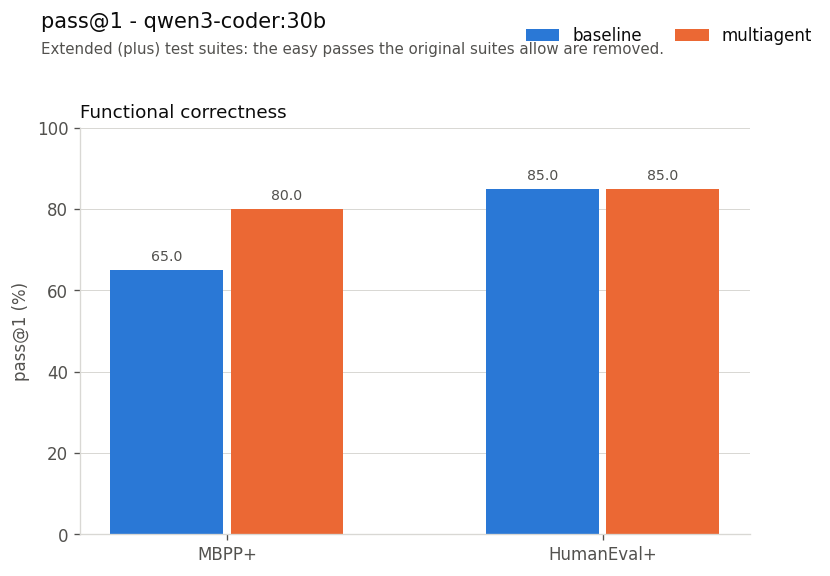

In [24]:
# --- Figure 1 : correctness -------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.4))
grouped(ax, "pass@1", "pass@1 (%)", "Functional correctness")
ax.set_ylim(0, 100)
fig.legend(handles=METHOD_HANDLES, loc="upper right", bbox_to_anchor=(0.99, 1.10), ncol=2)
fig.suptitle("pass@1 - %s" % MODEL_NAME, x=0.08, ha="left",
             fontsize=12.5, color=INK, y=1.10)
fig.text(0.08, 1.02, "Extended (plus) test suites: the easy passes the original "
                     "suites allow are removed.", ha="left", fontsize=9, color=INK_2)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_1_pass_at_1.png"))
plt.show()

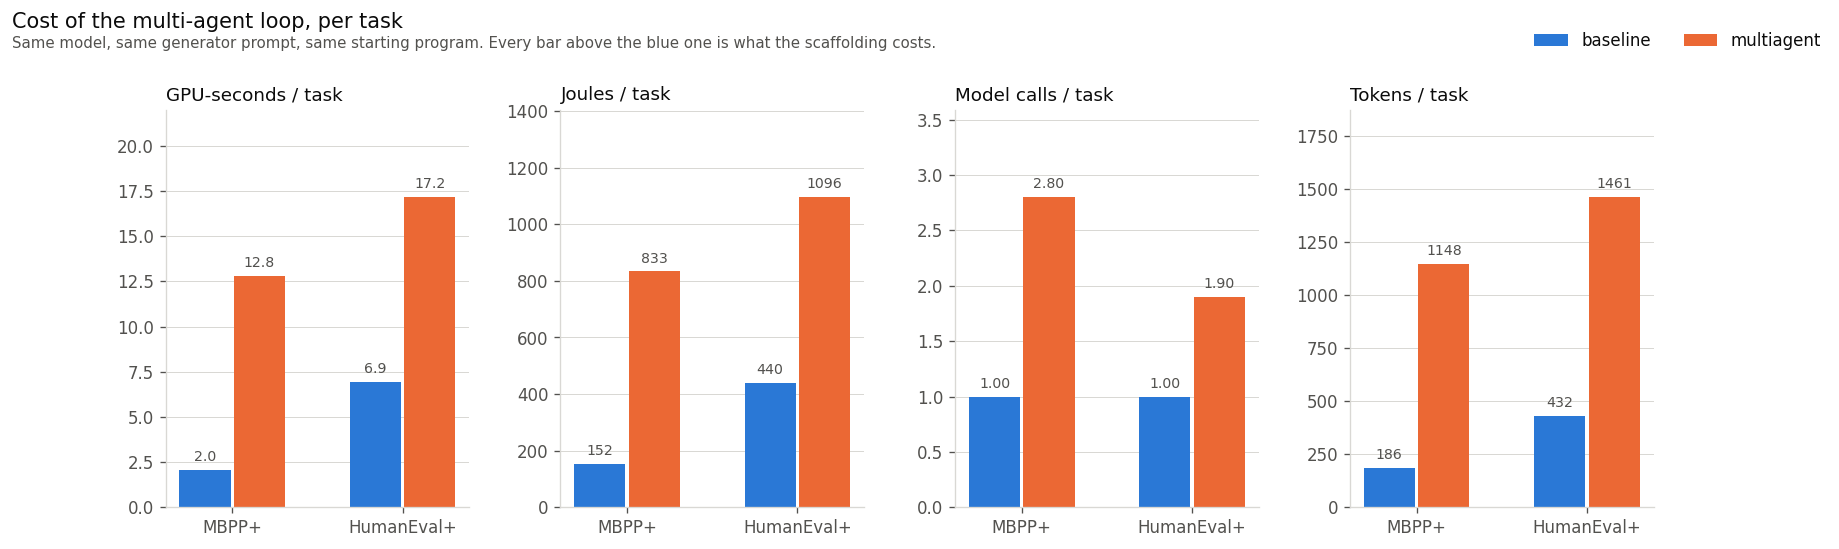

In [25]:
# --- Figure 2 : the cost axes, per task -------------------------------------
# Units live in the panel titles, so no y-labels compete for the gutters.
panels = [("gpu_s_per_task",  "GPU-seconds / task", "{:.1f}"),
          ("joules_per_task", "Joules / task",      "{:.0f}"),
          ("calls_per_task",  "Model calls / task", "{:.2f}"),
          ("tokens_per_task", "Tokens / task",      "{:.0f}")]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, (col, title, fmt) in zip(axes, panels):
    grouped(ax, col, None, title, fmt)
fig.legend(handles=METHOD_HANDLES, loc="upper right", bbox_to_anchor=(0.995, 1.06), ncol=2)
fig.suptitle("Cost of the multi-agent loop, per task", x=0.045, ha="left",
             fontsize=12.5, color=INK, y=1.07)
fig.text(0.045, 1.0, "Same model, same generator prompt, same starting program. Every bar "
                     "above the blue one is what the scaffolding costs.",
         ha="left", fontsize=9, color=INK_2)
fig.subplots_adjust(wspace=0.3)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_2_cost_axes.png"))
plt.show()

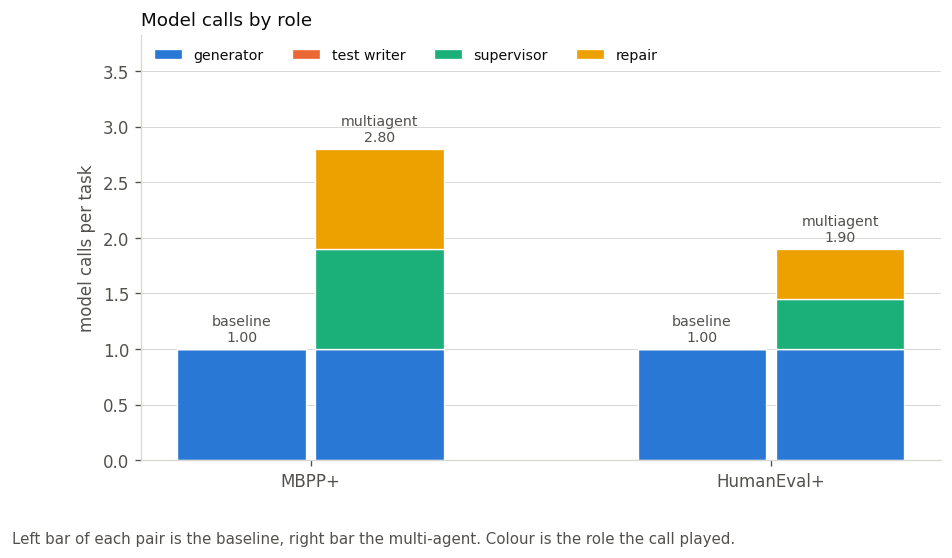

In [26]:
# --- Figure 3 : where the extra model calls go ------------------------------
# The baseline pays one generator call. Everything stacked above it is scaffolding.
fig, ax = plt.subplots(figsize=(8.6, 4.6))
# Stack order follows the palette's fixed slot order (blue, orange, aqua, yellow)
# so every touching pair is a validated adjacent pair, and 2px white separators
# keep the fills from bleeding into each other.
ROLE_COLS = [("gen_calls_per_task", "generator", "#2a78d6"),
             ("testwriter_calls_per_task", "test writer", "#eb6834"),
             ("supervisor_calls_per_task", "supervisor", "#1baf7a"),
             ("repair_calls_per_task", "repair", "#eda100")]

x, width = list(range(len(BENCH_TAGS))), 0.28
for k, m in enumerate(METHODS):
    off = (k - 0.5) * (width + GAP)
    bottom = [0.0] * len(BENCH_TAGS)
    for col, lab, colour in ROLE_COLS:
        vals = [mget(t, m, col) for t in BENCH_TAGS]
        vals = [0.0 if v != v else v for v in vals]
        ax.bar([xi + off for xi in x], vals, width=width, bottom=bottom,
               color=colour, linewidth=0.8, edgecolor="white",
               label=lab if k == 1 else None)
        bottom = [b + v for b, v in zip(bottom, vals)]
    for xi, b in zip(x, bottom):
        ax.text(xi + off, b + 0.04, "%s\n%.2f" % (m, b), ha="center", va="bottom",
                fontsize=8.5, color=INK_2)

ax.set_xticks(x); ax.set_xticklabels(BENCH_LABELS)
ax.set_ylabel("model calls per task"); ax.grid(axis="x", visible=False)
ax.set_title("Model calls by role", color=INK, loc="left")
headroom(ax, factor=1.3)
ax.legend(loc="upper left", fontsize=8.5, ncol=4)
fig.text(0.0, -0.04, "Left bar of each pair is the baseline, right bar the multi-agent. "
                     "Colour is the role the call played.",
         ha="left", fontsize=9, color=INK_2)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_3_calls_by_role.png"))
plt.show()

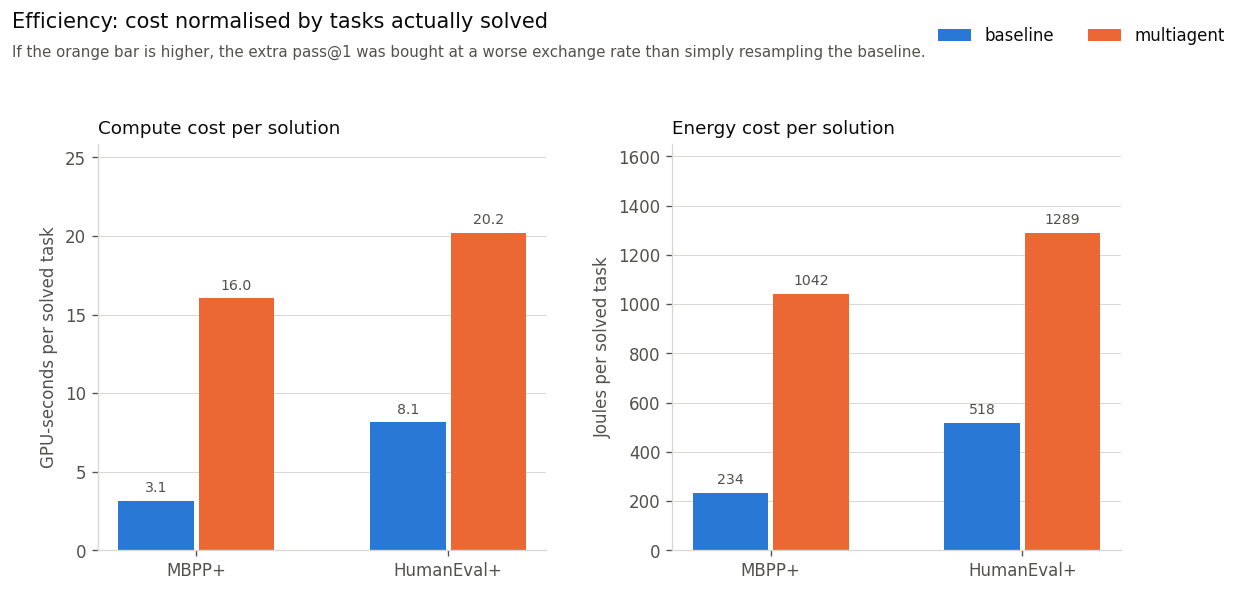

In [27]:
# --- Figure 4 : efficiency - what one solved task costs ---------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
grouped(axes[0], "gpu_s_per_solved", "GPU-seconds per solved task",
        "Compute cost per solution", "{:.1f}")
grouped(axes[1], "joules_per_solved", "Joules per solved task",
        "Energy cost per solution", "{:.0f}")
fig.legend(handles=METHOD_HANDLES, loc="upper right", bbox_to_anchor=(0.99, 1.13), ncol=2)
fig.suptitle("Efficiency: cost normalised by tasks actually solved", x=0.06, ha="left",
             fontsize=12.5, color=INK, y=1.13)
fig.text(0.06, 1.045, "If the orange bar is higher, the extra pass@1 was bought at a worse "
                      "exchange rate than simply resampling the baseline.",
         ha="left", fontsize=9, color=INK_2)
fig.subplots_adjust(wspace=0.28)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_4_efficiency.png"))
plt.show()

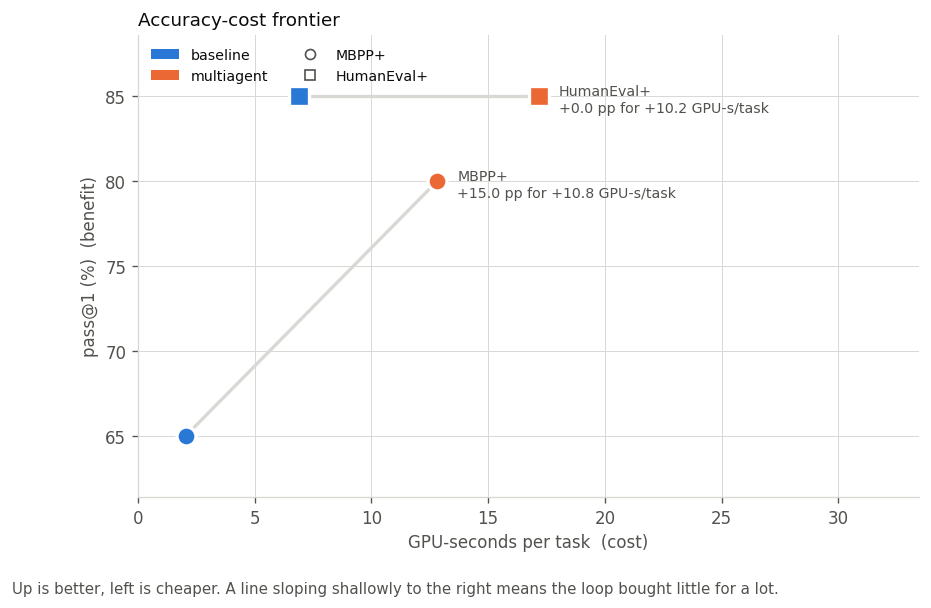

In [28]:
# --- Figure 5 : accuracy-vs-cost frontier -----------------------------------
# Colour means method; benchmark is carried by marker shape, so nothing has to be
# re-learned between figures. One label per line states the exchange rate.
fig, ax = plt.subplots(figsize=(8.4, 5.0))
MARKERS = ["o", "s", "^", "D"]
max_x = 0.0
for i, tag in enumerate(BENCH_TAGS):
    xs = [mget(tag, m, "gpu_s_per_task") for m in METHODS]
    ys = [mget(tag, m, "pass@1") for m in METHODS]
    max_x = max(max_x, max(xs))
    ax.plot(xs, ys, "-", color=GRID, linewidth=2, zorder=1)
    for m, xv, yv in zip(METHODS, xs, ys):
        ax.scatter([xv], [yv], s=130, color=METHOD_COLOR[m], marker=MARKERS[i % 4],
                   zorder=3, edgecolor="white", linewidth=2)
    ax.annotate("%s\n%+.1f pp for %+.1f GPU-s/task"
                % (M1_RESULTS[tag]["label"], ys[-1] - ys[0], xs[-1] - xs[0]),
                (xs[-1], ys[-1]), textcoords="offset points", xytext=(12, -2),
                ha="left", va="center", fontsize=8.5, color=INK_2)

handles = METHOD_HANDLES + [
    plt.Line2D([], [], marker=MARKERS[i % 4], color=INK_2, linestyle="none",
               markerfacecolor="none", label=M1_RESULTS[t]["label"])
    for i, t in enumerate(BENCH_TAGS)]
ax.legend(handles=handles, loc="upper left", fontsize=8.5, ncol=2)
ax.set_xlabel("GPU-seconds per task  (cost)")
ax.set_ylabel("pass@1 (%)  (benefit)")
ax.set_title("Accuracy-cost frontier", color=INK, loc="left")
ax.set_xlim(left=0, right=max(max_x * 1.95, 1e-9))
ax.margins(y=0.18)
fig.text(0.0, -0.05, "Up is better, left is cheaper. A line sloping shallowly to the right "
                     "means the loop bought little for a lot.",
         ha="left", fontsize=9, color=INK_2)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_5_frontier.png"))
plt.show()

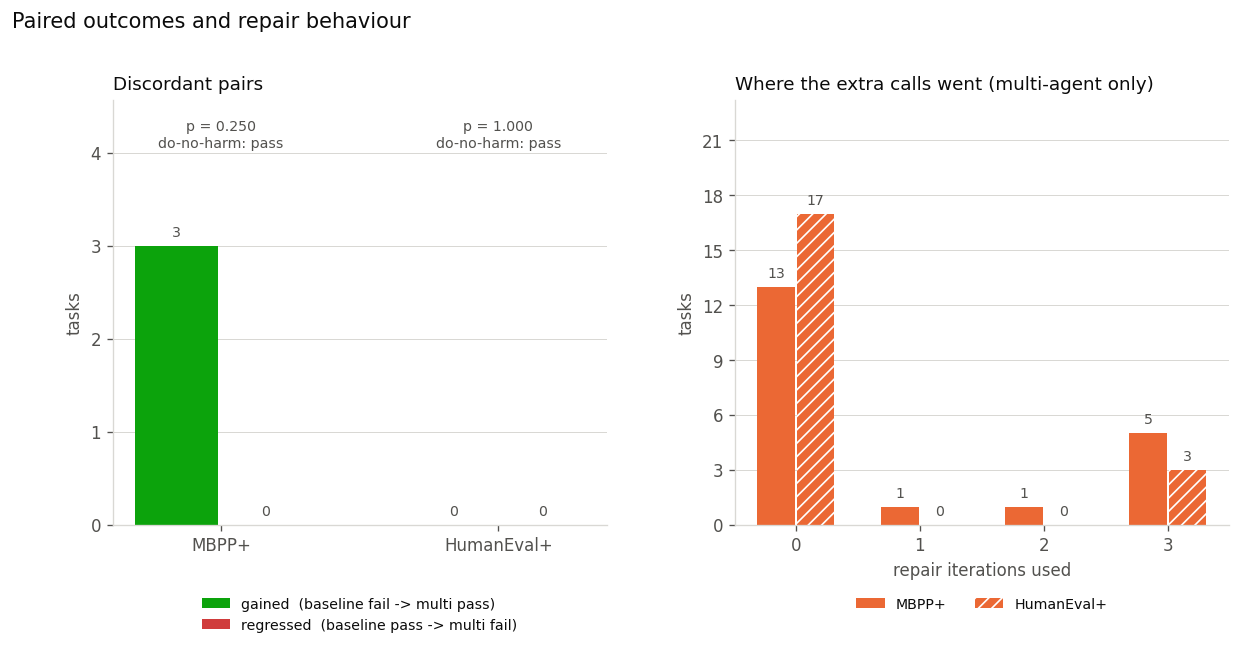

In [29]:
# --- Figure 6 : paired outcomes and repair behaviour ------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# (a) discordant cells - a good/bad axis, so status colours, not the series palette
ax = axes[0]
x = list(range(len(BENCH_TAGS)))
gains = [int(M1_STATS[M1_STATS.tag == t]["b01_gains"].iloc[0]) for t in BENCH_TAGS]
regs = [int(M1_STATS[M1_STATS.tag == t]["b10_regressions"].iloc[0]) for t in BENCH_TAGS]
ax.bar([xi - (BAR_W + GAP) / 2 for xi in x], gains, width=BAR_W, color=C_GOOD,
       linewidth=0, label="gained  (baseline fail -> multi pass)")
ax.bar([xi + (BAR_W + GAP) / 2 for xi in x], regs, width=BAR_W, color=C_CRITICAL,
       linewidth=0, label="regressed  (baseline pass -> multi fail)")
ax.set_xticks(x); ax.set_xticklabels(BENCH_LABELS)
ax.set_ylabel("tasks"); ax.grid(axis="x", visible=False)
ax.set_title("Discordant pairs", color=INK, loc="left")
headroom(ax, factor=1.45, integer=True)
for c in ax.containers:
    label_bars(ax, c, "{:.0f}")
ax.legend(loc="upper center", fontsize=8.5, bbox_to_anchor=(0.5, -0.14))
for xi, t in zip(x, BENCH_TAGS):
    r = M1_STATS[M1_STATS.tag == t].iloc[0]
    gate = "do-no-harm: pass" if r["do_no_harm_pass"] else "do-no-harm: FAIL"
    ax.annotate("p = %.3f\n%s" % (r["p_exact"], gate), (xi, ax.get_ylim()[1]),
                textcoords="offset points", xytext=(0, -12), ha="center", va="top",
                fontsize=8.5, color=INK_2 if r["do_no_harm_pass"] else C_CRITICAL)

# (b) repair iterations consumed. All bars are multi-agent data, so all keep the
#     multi-agent hue and the benchmark is carried by texture, not a second colour.
ax = axes[1]
maxit = int(max(int(M1_RESULTS[t]["df"]["iterations"].max()) for t in BENCH_TAGS))
HATCH = [None, "///", "...", "xxx"]
for k, t in enumerate(BENCH_TAGS):
    it = M1_RESULTS[t]["df"]["iterations"]
    counts = [int((it == r).sum()) for r in range(maxit + 1)]
    off = (k - (len(BENCH_TAGS) - 1) / 2) * (BAR_W + GAP)
    ax.bar([r + off for r in range(maxit + 1)], counts, width=BAR_W, color=C_MULTI,
           linewidth=0, hatch=HATCH[k % 4], edgecolor="white",
           label=M1_RESULTS[t]["label"])
ax.set_xticks(range(maxit + 1))
ax.set_xlabel("repair iterations used"); ax.set_ylabel("tasks")
ax.grid(axis="x", visible=False)
ax.set_title("Where the extra calls went (multi-agent only)", color=INK, loc="left")
headroom(ax, factor=1.3, integer=True)
for c in ax.containers:
    label_bars(ax, c, "{:.0f}")
ax.legend(loc="upper center", fontsize=8.5, ncol=2, bbox_to_anchor=(0.5, -0.14))

fig.suptitle("Paired outcomes and repair behaviour", x=0.055, ha="left",
             fontsize=12.5, color=INK, y=1.04)
fig.subplots_adjust(wspace=0.26)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_6_paired_outcomes.png"))
plt.show()

## 20 · Average model calls per question — baseline vs. repair

The baseline always makes exactly **1** call. The multi-agent makes 1 call when its first
program passes, and **1 + 2 per repair round** (supervisor + repair) when it does not. So its
average depends entirely on *how many questions enter repair and how many rounds they take*.
This cell breaks that down.

In [30]:
import numpy as np

def _nan():
    return float("nan")

crow = []
for tag, R in M1_RESULTS.items():
    df = R["df"]
    for method, prefix in [("baseline", "base_"), ("multiagent", "ma_")]:
        c = df[prefix + "calls_total"].astype(float)
        row = {"benchmark": R["label"], "system": method, "questions": len(df),
               "avg_calls_per_question": c.mean(), "median": c.median(),
               "max": int(c.max()), "total_calls": int(c.sum())}
        for k in ROLE_KEYS:
            row["avg_" + k + "_calls"] = df[prefix + "calls_" + k].astype(float).mean()
        if method == "multiagent":
            rep = ~df["multiagent_initial_pass"].astype(bool)
            row["questions_entering_repair"] = int(rep.sum())
            row["avg_calls_if_repaired"] = c[rep].mean() if rep.any() else _nan()
            row["avg_calls_if_first_try_passed"] = c[~rep].mean() if (~rep).any() else _nan()
            row["avg_repair_rounds_if_repaired"] = (df.loc[rep, "iterations"].mean()
                                                    if rep.any() else _nan())
            row["repaired_and_fixed"] = int(df["repair_success"].astype(bool).sum())
        crow.append(row)

CALLS_TABLE = pd.DataFrame(crow)
CALLS_TABLE.to_csv(os.path.join(M1_OUTPUT_DIR, "calls_per_question.csv"), index=False)

for tag, R in M1_RESULTS.items():
    lab = R["label"]
    b = CALLS_TABLE[(CALLS_TABLE.benchmark == lab) & (CALLS_TABLE.system == "baseline")].iloc[0]
    m = CALLS_TABLE[(CALLS_TABLE.benchmark == lab) & (CALLS_TABLE.system == "multiagent")].iloc[0]
    print("%s  (%d questions)" % (lab, b["questions"]))
    print("  baseline     : %.2f calls per question" % b["avg_calls_per_question"])
    print("  multi-agent  : %.2f calls per question  (%.1fx the baseline)"
          % (m["avg_calls_per_question"],
             m["avg_calls_per_question"] / max(b["avg_calls_per_question"], 1e-9)))
    print("     by role   : generator %.2f | supervisor %.2f | repair %.2f | test writer %.2f"
          % (m["avg_generator_calls"], m["avg_supervisor_calls"],
             m["avg_repair_calls"], m["avg_test_writer_calls"]))
    n_rep = m["questions_entering_repair"]
    print("     %d of %d questions passed on the first try and cost 1 call each"
          % (m["questions"] - n_rep, m["questions"]))
    if n_rep:
        print("     %d entered repair: %.2f calls and %.2f rounds on average; %d were fixed"
              % (n_rep, m["avg_calls_if_repaired"], m["avg_repair_rounds_if_repaired"],
                 m["repaired_and_fixed"]))
    print()

CALLS_TABLE[["benchmark", "system", "questions", "avg_calls_per_question", "median", "max",
             "avg_generator_calls", "avg_supervisor_calls", "avg_repair_calls",
             "avg_test_writer_calls"]].round(2)

MBPP+  (20 questions)
  baseline     : 1.00 calls per question
  multi-agent  : 2.80 calls per question  (2.8x the baseline)
     by role   : generator 1.00 | supervisor 0.90 | repair 0.90 | test writer 0.00
     13 of 20 questions passed on the first try and cost 1 call each
     7 entered repair: 6.14 calls and 2.57 rounds on average; 3 were fixed

HumanEval+  (20 questions)
  baseline     : 1.00 calls per question
  multi-agent  : 1.90 calls per question  (1.9x the baseline)
     by role   : generator 1.00 | supervisor 0.45 | repair 0.45 | test writer 0.00
     17 of 20 questions passed on the first try and cost 1 call each
     3 entered repair: 7.00 calls and 3.00 rounds on average; 0 were fixed



,benchmark,system,questions,avg_calls_per_question,median,max,avg_generator_calls,avg_supervisor_calls,avg_repair_calls,avg_test_writer_calls
0,MBPP+,baseline,20,1.0,1.0,1,1.0,0.00,0.00,0.0
1,MBPP+,multiagent,20,2.8,1.0,7,1.0,0.90,0.90,0.0
2,HumanEval+,baseline,20,1.0,1.0,1,1.0,0.00,0.00,0.0
3,HumanEval+,multiagent,20,1.9,1.0,7,1.0,0.45,0.45,0.0


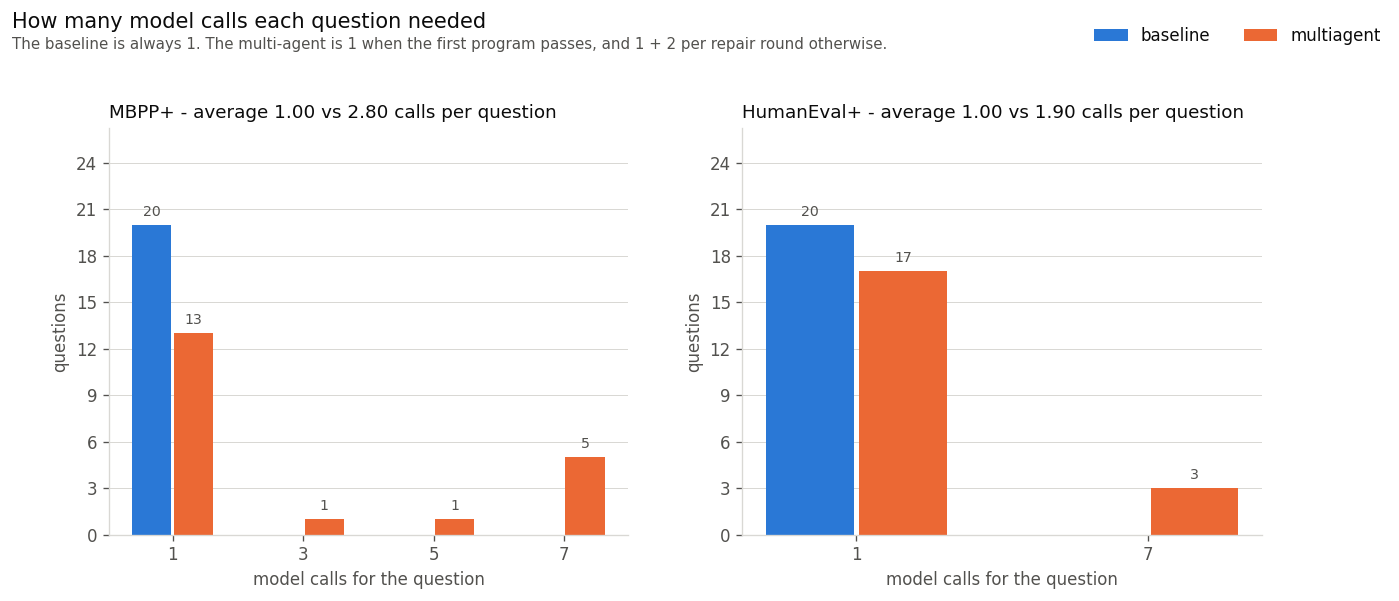

In [31]:
# --- Figure 7 : distribution of model calls per question --------------------
fig, axes = plt.subplots(1, len(BENCH_TAGS), figsize=(6.2 * len(BENCH_TAGS), 4.4),
                         squeeze=False)
for ax, tag in zip(axes[0], BENCH_TAGS):
    df = M1_RESULTS[tag]["df"]
    cb = df["base_calls_total"].astype(int)
    cm = df["ma_calls_total"].astype(int)
    xs = sorted(set(cb) | set(cm))
    pos = list(range(len(xs)))
    for k, (series, m) in enumerate([(cb, "baseline"), (cm, "multiagent")]):
        off = (k - 0.5) * (BAR_W + GAP)
        ax.bar([p + off for p in pos], [int((series == v).sum()) for v in xs],
               width=BAR_W, color=METHOD_COLOR[m], linewidth=0)
    ax.set_xticks(pos); ax.set_xticklabels([str(v) for v in xs])
    ax.set_xlabel("model calls for the question"); ax.set_ylabel("questions")
    ax.grid(axis="x", visible=False)
    headroom(ax, factor=1.25, integer=True)
    for c in ax.containers:
        label_bars(ax, [b for b in c if b.get_height() > 0], "{:.0f}")
    ax.set_title("%s - average %.2f vs %.2f calls per question"
                 % (M1_RESULTS[tag]["label"], cb.mean(), cm.mean()), color=INK, loc="left")

fig.legend(handles=METHOD_HANDLES, loc="upper right", bbox_to_anchor=(0.99, 1.10), ncol=2)
fig.suptitle("How many model calls each question needed", x=0.06, ha="left",
             fontsize=12.5, color=INK, y=1.10)
fig.text(0.06, 1.03, "The baseline is always 1. The multi-agent is 1 when the first program "
         "passes, and 1 + 2 per repair round otherwise.", ha="left", fontsize=9, color=INK_2)
fig.subplots_adjust(wspace=0.22)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_7_calls_per_question.png"))
plt.show()

## 21 · Cost of each agent inside the multi-agent

The multi-agent is several agents sharing one model. This section measures **every metric
separately for each of them**, per call and per question:

| Agent | What it does | Runs on |
|---|---|---|
| **Code agent — first draft** | writes the initial program (the same call the baseline makes) | GPU |
| **Test agent** | writes extra tests (only when `USE_TEST_AGENT = True`) | GPU |
| **Supervisor** | reads the failing test output and diagnoses the bug | GPU |
| **Code agent — repair** | rewrites the program using the supervisor's diagnosis | GPU |
| **Executor (sandbox)** | runs the program against the tests | CPU |

Metrics per agent: model calls, prompt and completion tokens, GPU-seconds, joules (total and
above idle), wall time, average power, and each agent's **share** of the multi-agent's total.
The executor has no GPU-seconds or joules: it runs on the CPU, which NVML does not meter, so it
is reported by executions and time only.

The first-draft row is exactly what the baseline spends per question, so everything below it
in the table is the price of the repair loop.

In [32]:
AGENTS = [("generator",   "Code agent - first draft"),
          ("test_writer", "Test agent"),
          ("supervisor",  "Supervisor"),
          ("repair",      "Code agent - repair")]
AGENT_COLOR = {"generator": "#2a78d6", "test_writer": "#eb6834",
               "supervisor": "#1baf7a", "repair": "#eda100"}     # same as Figure 3
AGENT_LABEL = dict(AGENTS)
_N = max(M1_CONFIG["N_GPUS"], 1)
_IDLE = M1_CONFIG["IDLE_WATTS"]

agent_rows, check_rows = [], []
for tag, R in M1_RESULTS.items():
    df = R["df"]
    nq = len(df)
    calls = pd.DataFrame(R["calls"])
    ma = calls[calls["system"] == "multiagent"] if len(calls) else calls
    tot_gpu = ma["gpu_seconds"].sum() if len(ma) else 0.0
    tot_j = ma["joules"].sum() if len(ma) else 0.0
    tot_tok = (ma["prompt_tokens"].sum() + ma["completion_tokens"].sum()) if len(ma) else 0
    tot_calls = len(ma)

    for role, label in AGENTS:
        a = ma[ma["role"] == role] if len(ma) else ma
        n = len(a)
        gpu = float(a["gpu_seconds"].sum()) if n else 0.0
        j = float(a["joules"].sum()) if n else 0.0
        pt = int(a["prompt_tokens"].sum()) if n else 0
        ct = int(a["completion_tokens"].sum()) if n else 0
        wall = float(a["wall_seconds"].sum()) if n else 0.0
        j_ai = max(j - _IDLE * gpu / _N, 0.0) if (_IDLE == _IDLE and j == j) else np.nan
        agent_rows.append({
            "benchmark": R["label"], "agent": label, "role": role, "device": "GPU",
            "questions": nq, "calls": n, "calls_per_question": n / nq,
            "questions_using_agent": int(a["task_id"].nunique()) if n else 0,
            "prompt_tokens": pt, "completion_tokens": ct,
            "prompt_tokens_per_call": pt / n if n else np.nan,
            "completion_tokens_per_call": ct / n if n else np.nan,
            "tokens_per_question": (pt + ct) / nq,
            "gpu_seconds": gpu, "gpu_s_per_call": gpu / n if n else np.nan,
            "gpu_s_per_question": gpu / nq,
            "joules": j, "joules_per_call": j / n if n else np.nan,
            "joules_per_question": j / nq,
            "joules_above_idle": j_ai, "joules_above_idle_per_question": j_ai / nq,
            "wall_seconds": wall,
            "mean_power_w_per_card": (j / gpu) if gpu > 0 else np.nan,
            "share_calls_%": 100.0 * n / tot_calls if tot_calls else np.nan,
            "share_tokens_%": 100.0 * (pt + ct) / tot_tok if tot_tok else np.nan,
            "share_gpu_s_%": 100.0 * gpu / tot_gpu if tot_gpu else np.nan,
            "share_energy_%": 100.0 * j / tot_j if tot_j else np.nan,
        })

    # executor: one sandbox run for the first draft + one per repair round
    execs = int((1 + df["iterations"]).sum())
    exec_s = float(df["ma_execution_time"].sum())
    agent_rows.append({
        "benchmark": R["label"], "agent": "Executor (sandbox)", "role": "executor",
        "device": "CPU", "questions": nq, "calls": execs, "calls_per_question": execs / nq,
        "questions_using_agent": nq, "wall_seconds": exec_s,
        "gpu_seconds": 0.0, "gpu_s_per_question": 0.0, "joules": np.nan,
        "share_gpu_s_%": 0.0,
    })

    # reconcile: per-agent sums must equal the per-question totals from section 16
    check_rows.append((R["label"], tot_gpu, float(df["ma_gpu_seconds"].sum()),
                       tot_calls, int(df["ma_calls_total"].sum())))

AGENT_TABLE = pd.DataFrame(agent_rows)
AGENT_TABLE.to_csv(os.path.join(M1_OUTPUT_DIR, "per_agent_costs.csv"), index=False)

for lab, g1, g2, c1, c2 in check_rows:
    ok = abs(g1 - g2) < 1e-6 and c1 == c2
    print("%-11s reconciliation: per-agent sums %s the per-question totals "
          "(%.1f GPU-s, %d calls)" % (lab, "match" if ok else "DO NOT MATCH", g2, c2))
print()

for tag, R in M1_RESULTS.items():
    t = AGENT_TABLE[AGENT_TABLE.benchmark == R["label"]]
    print("%s - multi-agent, averages per question (%d questions)" % (R["label"], t["questions"].iloc[0]))
    print("  %-26s %6s %8s %7s %7s %7s  %s" % ("agent", "calls", "tokens", "GPU-s", "J",
                                               "J>idle", "share of GPU-s / energy"))
    for r in t.to_dict("records"):
        if r["role"] == "executor":
            print("  %-26s %6.2f %8s %7s %7s %7s  CPU only: %.2f s of sandbox time per question"
                  % (r["agent"], r["calls_per_question"], "-", "-", "-", "-",
                     r["wall_seconds"] / r["questions"]))
            continue
        if r["calls"] == 0:
            print("  %-26s %6.2f %8s %7s %7s %7s  not used" % (r["agent"], 0, "-", "-", "-", "-"))
            continue
        print("  %-26s %6.2f %8.0f %7.2f %7.0f %7.0f  %3.0f%% / %3.0f%%"
              % (r["agent"], r["calls_per_question"], r["tokens_per_question"],
                 r["gpu_s_per_question"], r["joules_per_question"],
                 r["joules_above_idle_per_question"], r["share_gpu_s_%"], r["share_energy_%"]))
    g = t[t.role == "generator"]; rp = t[t.role == "repair"]; sv = t[t.role == "supervisor"]
    if len(g) and len(rp) and g["calls"].iloc[0] and rp["calls"].iloc[0]:
        print("  -> one repair call costs %.1fx a first-draft call in GPU-seconds "
              "(%.0f vs %.0f prompt tokens per call)"
              % (rp["gpu_s_per_call"].iloc[0] / g["gpu_s_per_call"].iloc[0],
                 rp["prompt_tokens_per_call"].iloc[0], g["prompt_tokens_per_call"].iloc[0]))
    if len(sv) and sv["calls"].iloc[0]:
        print("  -> the supervisor alone uses %.0f%% of the multi-agent's energy"
              % sv["share_energy_%"].iloc[0])
    print()

AGENT_TABLE[["benchmark", "agent", "calls", "calls_per_question", "prompt_tokens_per_call",
             "completion_tokens_per_call", "gpu_s_per_call", "joules_per_call",
             "gpu_s_per_question", "joules_per_question", "mean_power_w_per_card",
             "share_gpu_s_%", "share_energy_%"]].round(2)

MBPP+       reconciliation: per-agent sums match the per-question totals (256.4 GPU-s, 56 calls)
HumanEval+  reconciliation: per-agent sums match the per-question totals (343.3 GPU-s, 38 calls)

MBPP+ - multi-agent, averages per question (20 questions)
  agent                       calls   tokens   GPU-s       J  J>idle  share of GPU-s / energy
  Code agent - first draft     1.00      186    2.05     152      96   16% /  18%
  Test agent                   0.00        -       -       -       -  not used
  Supervisor                   0.90      417    5.16     325     183   40% /  39%
  Code agent - repair          0.90      545    5.61     357     202   44% /  43%
  Executor (sandbox)           1.90        -       -       -       -  CPU only: 0.40 s of sandbox time per question
  -> one repair call costs 3.0x a first-draft call in GPU-seconds (431 vs 134 prompt tokens per call)
  -> the supervisor alone uses 39% of the multi-agent's energy

HumanEval+ - multi-agent, averages per questio

,benchmark,agent,calls,calls_per_question,prompt_tokens_per_call,completion_tokens_per_call,gpu_s_per_call,joules_per_call,gpu_s_per_question,joules_per_question,mean_power_w_per_card,share_gpu_s_%,share_energy_%
0,MBPP+,Code agent - first draft,20,1.00,134.15,51.35,2.05,151.95,2.05,151.95,74.27,15.96,18.23
1,MBPP+,Test agent,0,0.00,NaN,NaN,NaN,NaN,0.00,0.00,NaN,0.00,0.00
2,MBPP+,Supervisor,18,0.90,299.67,163.67,5.74,360.82,5.16,324.74,62.91,40.26,38.97
3,MBPP+,Code agent - repair,18,0.90,430.83,175.11,6.24,396.23,5.61,356.61,63.51,43.79,42.79
4,MBPP+,Executor (sandbox),38,1.90,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN
5,HumanEval+,Code agent - first draft,20,1.00,223.85,208.05,6.92,440.16,6.92,440.16,63.65,40.29,40.17
6,HumanEval+,Test agent,0,0.00,NaN,NaN,NaN,NaN,0.00,0.00,NaN,0.00,0.00
7,HumanEval+,Supervisor,9,0.45,671.67,351.11,11.76,753.65,5.29,339.14,64.08,30.84,30.95
8,HumanEval+,Code agent - repair,9,0.45,953.56,311.00,11.01,703.18,4.95,316.43,63.86,28.87,28.88
9,HumanEval+,Executor (sandbox),29,1.45,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN


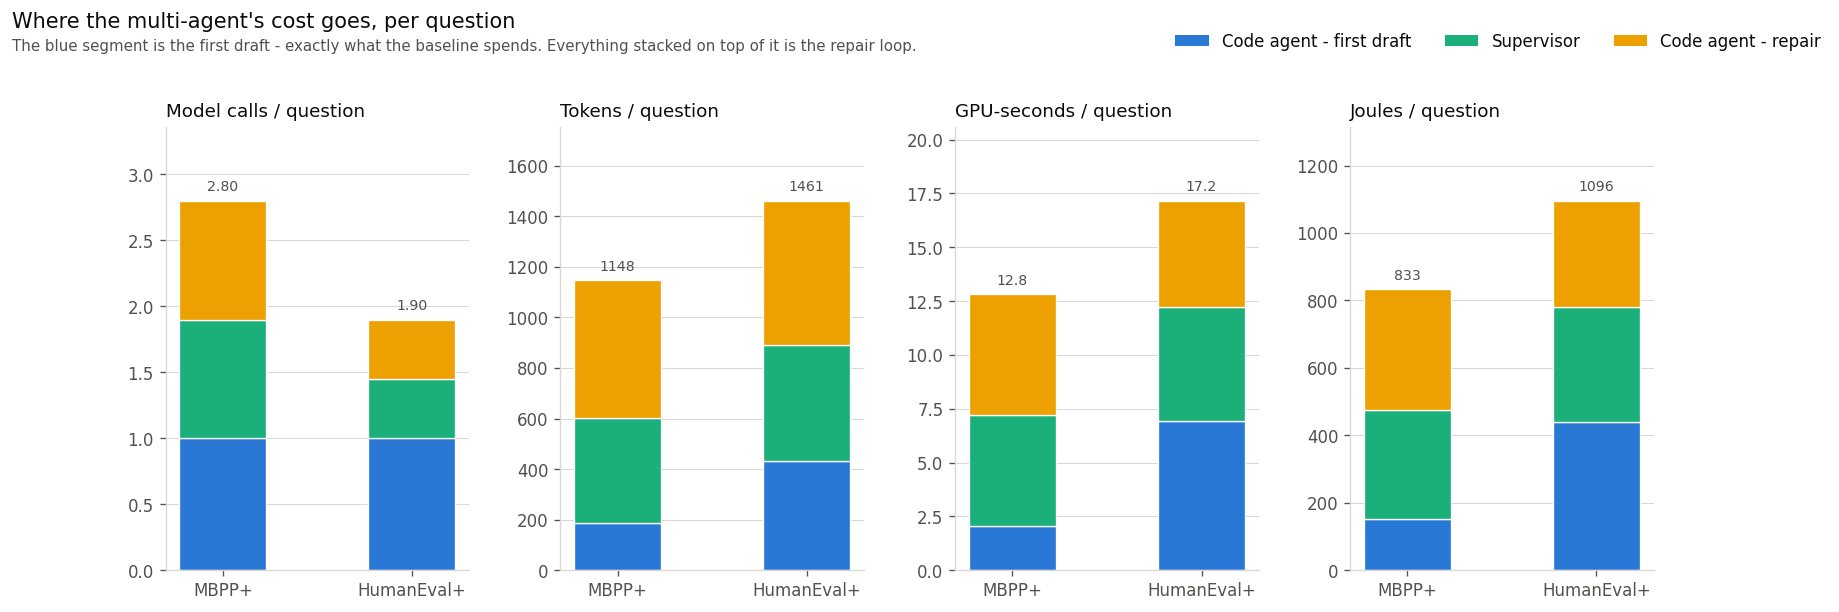

In [33]:
# --- Figure 10 : where the multi-agent's cost goes, per question ------------
used = [r for r, _ in AGENTS
        if AGENT_TABLE[(AGENT_TABLE.role == r)]["calls"].sum() > 0]
panels = [("calls_per_question", "Model calls / question", "{:.2f}"),
          ("tokens_per_question", "Tokens / question", "{:.0f}"),
          ("gpu_s_per_question", "GPU-seconds / question", "{:.1f}"),
          ("joules_per_question", "Joules / question", "{:.0f}")]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.8))
x = list(range(len(BENCH_TAGS)))
for ax, (col, title, fmt) in zip(axes, panels):
    bottom = [0.0] * len(x)
    for role in used:
        vals = []
        for t in BENCH_TAGS:
            r = AGENT_TABLE[(AGENT_TABLE.benchmark == M1_RESULTS[t]["label"]) &
                            (AGENT_TABLE.role == role)]
            v = float(r[col].iloc[0]) if len(r) else 0.0
            vals.append(0.0 if v != v else v)
        ax.bar(x, vals, width=0.46, bottom=bottom, color=AGENT_COLOR[role],
               edgecolor="white", linewidth=0.8)
        bottom = [b + v for b, v in zip(bottom, vals)]
    top = max(bottom) if max(bottom) > 0 else 1.0
    ax.set_ylim(0, top * 1.2)
    for xi, b in zip(x, bottom):
        ax.text(xi, b + 0.015 * ax.get_ylim()[1], fmt.format(b), ha="center",
                va="bottom", fontsize=8.5, color=INK_2)
    ax.set_xticks(x); ax.set_xticklabels(BENCH_LABELS)
    ax.set_title(title, color=INK, loc="left"); ax.grid(axis="x", visible=False)

fig.legend(handles=[Patch(facecolor=AGENT_COLOR[r], label=AGENT_LABEL[r]) for r in used],
           loc="upper right", bbox_to_anchor=(0.995, 1.07), ncol=len(used))
fig.suptitle("Where the multi-agent's cost goes, per question", x=0.045, ha="left",
             fontsize=12.5, color=INK, y=1.08)
fig.text(0.045, 1.012, "The blue segment is the first draft - exactly what the baseline spends. "
         "Everything stacked on top of it is the repair loop.",
         ha="left", fontsize=9, color=INK_2)
fig.subplots_adjust(wspace=0.3)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_10_cost_by_agent.png"))
plt.show()

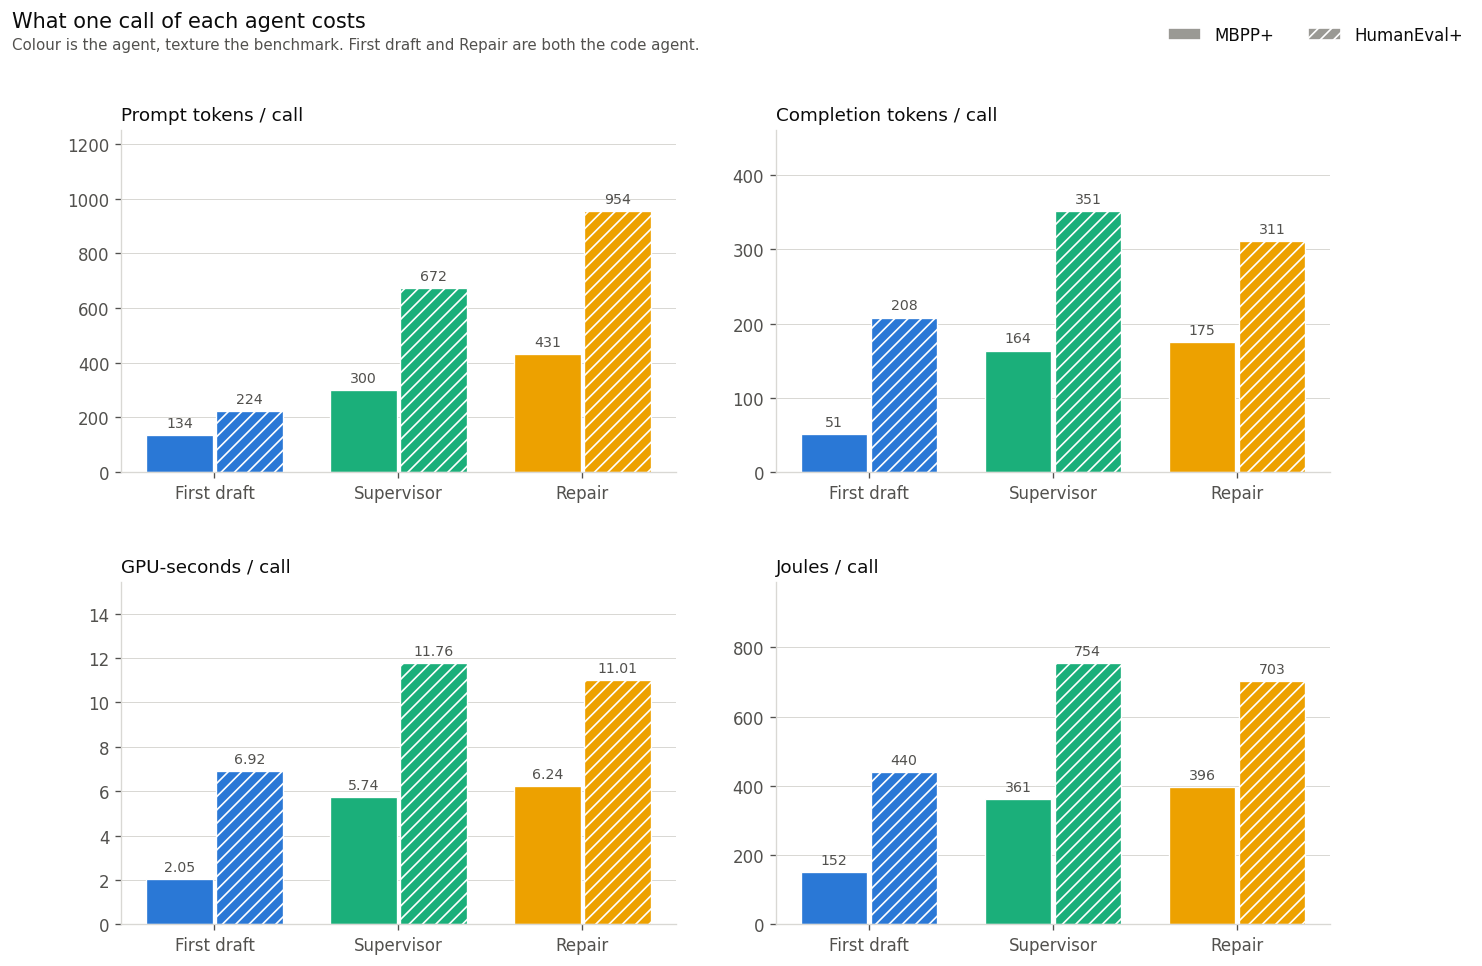

In [34]:
# --- Figure 11 : what ONE call of each agent costs --------------------------
panels = [("prompt_tokens_per_call", "Prompt tokens / call", "{:.0f}"),
          ("completion_tokens_per_call", "Completion tokens / call", "{:.0f}"),
          ("gpu_s_per_call", "GPU-seconds / call", "{:.2f}"),
          ("joules_per_call", "Joules / call", "{:.0f}")]
HATCH_B = [None, "///", "...", "xxx"]

SHORT = {"generator": "First draft", "test_writer": "Test agent",
         "supervisor": "Supervisor", "repair": "Repair"}
fig, axes = plt.subplots(2, 2, figsize=(13, 8.6))
axes = axes.ravel()
pos = list(range(len(used)))
nb_ = len(BENCH_TAGS)
w = 0.36 if nb_ > 1 else 0.5
for ax, (col, title, fmt) in zip(axes, panels):
    for k, t in enumerate(BENCH_TAGS):
        off = (k - (nb_ - 1) / 2) * (w + GAP)
        vals = []
        for role in used:
            r = AGENT_TABLE[(AGENT_TABLE.benchmark == M1_RESULTS[t]["label"]) &
                            (AGENT_TABLE.role == role)]
            v = float(r[col].iloc[0]) if len(r) else np.nan
            vals.append(0.0 if v != v else v)
        ax.bar([p + off for p in pos], vals, width=w,
               color=[AGENT_COLOR[r] for r in used], hatch=HATCH_B[k % 4],
               edgecolor="white", linewidth=0.8)
    headroom(ax, factor=1.25)
    for c in ax.containers:
        label_bars(ax, [b for b in c if b.get_height() > 0], fmt)
    ax.set_xticks(pos)
    ax.set_xticklabels([SHORT[r] for r in used])
    ax.set_title(title, color=INK, loc="left"); ax.grid(axis="x", visible=False)

fig.legend(handles=[Patch(facecolor="#9a9994", hatch=HATCH_B[k % 4], edgecolor="white",
                          label=M1_RESULTS[t]["label"]) for k, t in enumerate(BENCH_TAGS)],
           loc="upper right", bbox_to_anchor=(0.995, 0.995), ncol=nb_)
fig.suptitle("What one call of each agent costs", x=0.055, ha="left",
             fontsize=12.5, color=INK, y=0.995)
fig.text(0.055, 0.958, "Colour is the agent, texture the benchmark. First draft and Repair are "
         "both the code agent.",
         ha="left", fontsize=9, color=INK_2)
fig.subplots_adjust(top=0.88, hspace=0.32, wspace=0.18)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_11_cost_per_call_by_agent.png"))
plt.show()

## 22 · How the metrics drive each other

Each point below is **one question under one system**. For every pair of metrics the cell fits
a straight line and reports:

- the **marginal rate** — e.g. how many GPU-seconds one extra model call adds, or how many joules
  one GPU-second costs;
- **R²** — how much of the variation in one metric the other explains.

The key comparison is **model calls vs. tokens as predictors of GPU-seconds and energy.** If
tokens explain cost much better than calls do, then counting calls understates what the repair
loop really costs, because repair prompts carry the previous program and the reviewer's feedback.

Rates are fitted on all tasks, and separately on multi-agent tasks only: pooling both systems lets
the 1-call baseline dominate the call axis, so the multi-agent-only fit is the fairer read.

In [35]:
# --- one row per (question, system) -----------------------------------------
long_rows = []
for tag, R in M1_RESULTS.items():
    df = R["df"]
    for method, prefix, passcol in [("baseline", "base_", "baseline_final_pass"),
                                    ("multiagent", "ma_", "multiagent_final_pass")]:
        for _, r in df.iterrows():
            long_rows.append({
                "benchmark": R["label"], "system": method, "task_id": r["task_id"],
                "passed": bool(r[passcol]),
                "model_calls": float(r[prefix + "calls_total"]),
                "tokens": float(r[prefix + "total_tokens"]),
                "gpu_seconds": float(r[prefix + "gpu_seconds"]),
                "joules": float(r[prefix + "joules"]),
                "joules_above_idle": float(r[prefix + "joules_above_idle"]),
                "wall_seconds": float(r[prefix + "wall_seconds"]),
            })
TASKS_LONG = pd.DataFrame(long_rows)
TASKS_LONG.to_csv(os.path.join(M1_OUTPUT_DIR, "per_question_costs.csv"), index=False)


def fit_line(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 3 or np.ptp(x) == 0 or np.ptp(y) == 0:
        return {"n": int(len(x)), "slope": np.nan, "intercept": np.nan, "r": np.nan, "r2": np.nan}
    slope, intercept = np.polyfit(x, y, 1)
    r = float(np.corrcoef(x, y)[0, 1])
    return {"n": int(len(x)), "slope": float(slope), "intercept": float(intercept),
            "r": r, "r2": r * r}


# (x, y, x label, y label, rate multiplier, rate unit)
PAIRS = [
    ("model_calls", "gpu_seconds", "model calls", "GPU-seconds", 1,    "GPU-s per extra call"),
    ("model_calls", "joules",      "model calls", "joules",      1,    "J per extra call"),
    ("tokens",      "gpu_seconds", "tokens",      "GPU-seconds", 1000, "GPU-s per 1k tokens"),
    ("tokens",      "joules",      "tokens",      "joules",      1000, "J per 1k tokens"),
    ("gpu_seconds", "joules",      "GPU-seconds", "joules",      1,    "J per GPU-second (= W per card)"),
    ("model_calls", "tokens",      "model calls", "tokens",      1,    "tokens per extra call"),
]

rel_rows = []
for scope, sub in [("all questions", TASKS_LONG),
                   ("multi-agent only", TASKS_LONG[TASKS_LONG.system == "multiagent"])]:
    for x, y, xl, yl, mult, unit in PAIRS:
        f = fit_line(sub[x], sub[y])
        rel_rows.append({"scope": scope, "x": x, "y": y, "rate": f["slope"] * mult,
                         "rate_unit": unit, "pearson_r": f["r"], "r_squared": f["r2"],
                         "n": f["n"]})
RELATIONS = pd.DataFrame(rel_rows)
RELATIONS.to_csv(os.path.join(M1_OUTPUT_DIR, "metric_relationships.csv"), index=False)


def rel(x, y, scope="all questions"):
    r = RELATIONS[(RELATIONS.scope == scope) & (RELATIONS.x == x) & (RELATIONS.y == y)]
    return r.iloc[0] if len(r) else None


def pct(v):
    return "n/a" if v != v else "%.0f%%" % (100 * v)


print("What the per-question data says\n")
c_g, c_j = rel("model_calls", "gpu_seconds"), rel("model_calls", "joules")
t_g, t_j = rel("tokens", "gpu_seconds"), rel("tokens", "joules")
g_j = rel("gpu_seconds", "joules")
print("1. One extra model call adds about %.1f GPU-seconds and %.0f J."
      % (c_g["rate"], c_j["rate"]))
print("2. One thousand extra tokens add about %.1f GPU-seconds and %.0f J."
      % (t_g["rate"], t_j["rate"]))
for scope in ["all questions", "multi-agent only"]:
    a, b = rel("model_calls", "gpu_seconds", scope), rel("tokens", "gpu_seconds", scope)
    print("3. GPU-seconds explained [%s]: tokens %s vs model calls %s"
          % (scope, pct(b["r_squared"]), pct(a["r_squared"])))
idle_card = M1_CONFIG["IDLE_WATTS"] / max(M1_CONFIG["N_GPUS"], 1)
print("4. Energy follows GPU time: about %.0f J per GPU-second, i.e. ~%.0f W per card while\n"
      "   generating (idle with the model resident: ~%.0f W per card). R^2 = %s."
      % (g_j["rate"], g_j["rate"], idle_card, pct(g_j["r_squared"])))
m_t = rel("model_calls", "tokens", "multi-agent only")
print("5. Within the multi-agent, each extra call carries about %.0f tokens." % m_t["rate"])

RELATIONS.round(3)

What the per-question data says

1. One extra model call adds about 8.2 GPU-seconds and 530 J.
2. One thousand extra tokens add about 10.8 GPU-seconds and 690 J.
3. GPU-seconds explained [all questions]: tokens 97% vs model calls 77%
3. GPU-seconds explained [multi-agent only]: tokens 98% vs model calls 77%
4. Energy follows GPU time: about 64 J per GPU-second, i.e. ~64 W per card while
   generating (idle with the model resident: ~27 W per card). R^2 = 99%.
5. Within the multi-agent, each extra call carries about 771 tokens.


,scope,x,y,rate,rate_unit,pearson_r,r_squared,n
0,all questions,model_calls,gpu_seconds,8.187,GPU-s per extra call,0.879,0.772,80
1,all questions,model_calls,joules,529.671,J per extra call,0.884,0.781,80
2,all questions,tokens,gpu_seconds,10.764,GPU-s per 1k tokens,0.987,0.975,80
3,all questions,tokens,joules,690.317,J per 1k tokens,0.985,0.969,80
4,all questions,gpu_seconds,joules,64.147,J per GPU-second (= W per card),0.997,0.995,80
5,all questions,model_calls,tokens,766.868,tokens per extra call,0.897,0.805,80
6,multi-agent only,model_calls,gpu_seconds,8.249,GPU-s per extra call,0.875,0.766,40
7,multi-agent only,model_calls,joules,535.022,J per extra call,0.883,0.779,40
8,multi-agent only,tokens,gpu_seconds,10.729,GPU-s per 1k tokens,0.989,0.978,40
9,multi-agent only,tokens,joules,689.001,J per 1k tokens,0.987,0.974,40


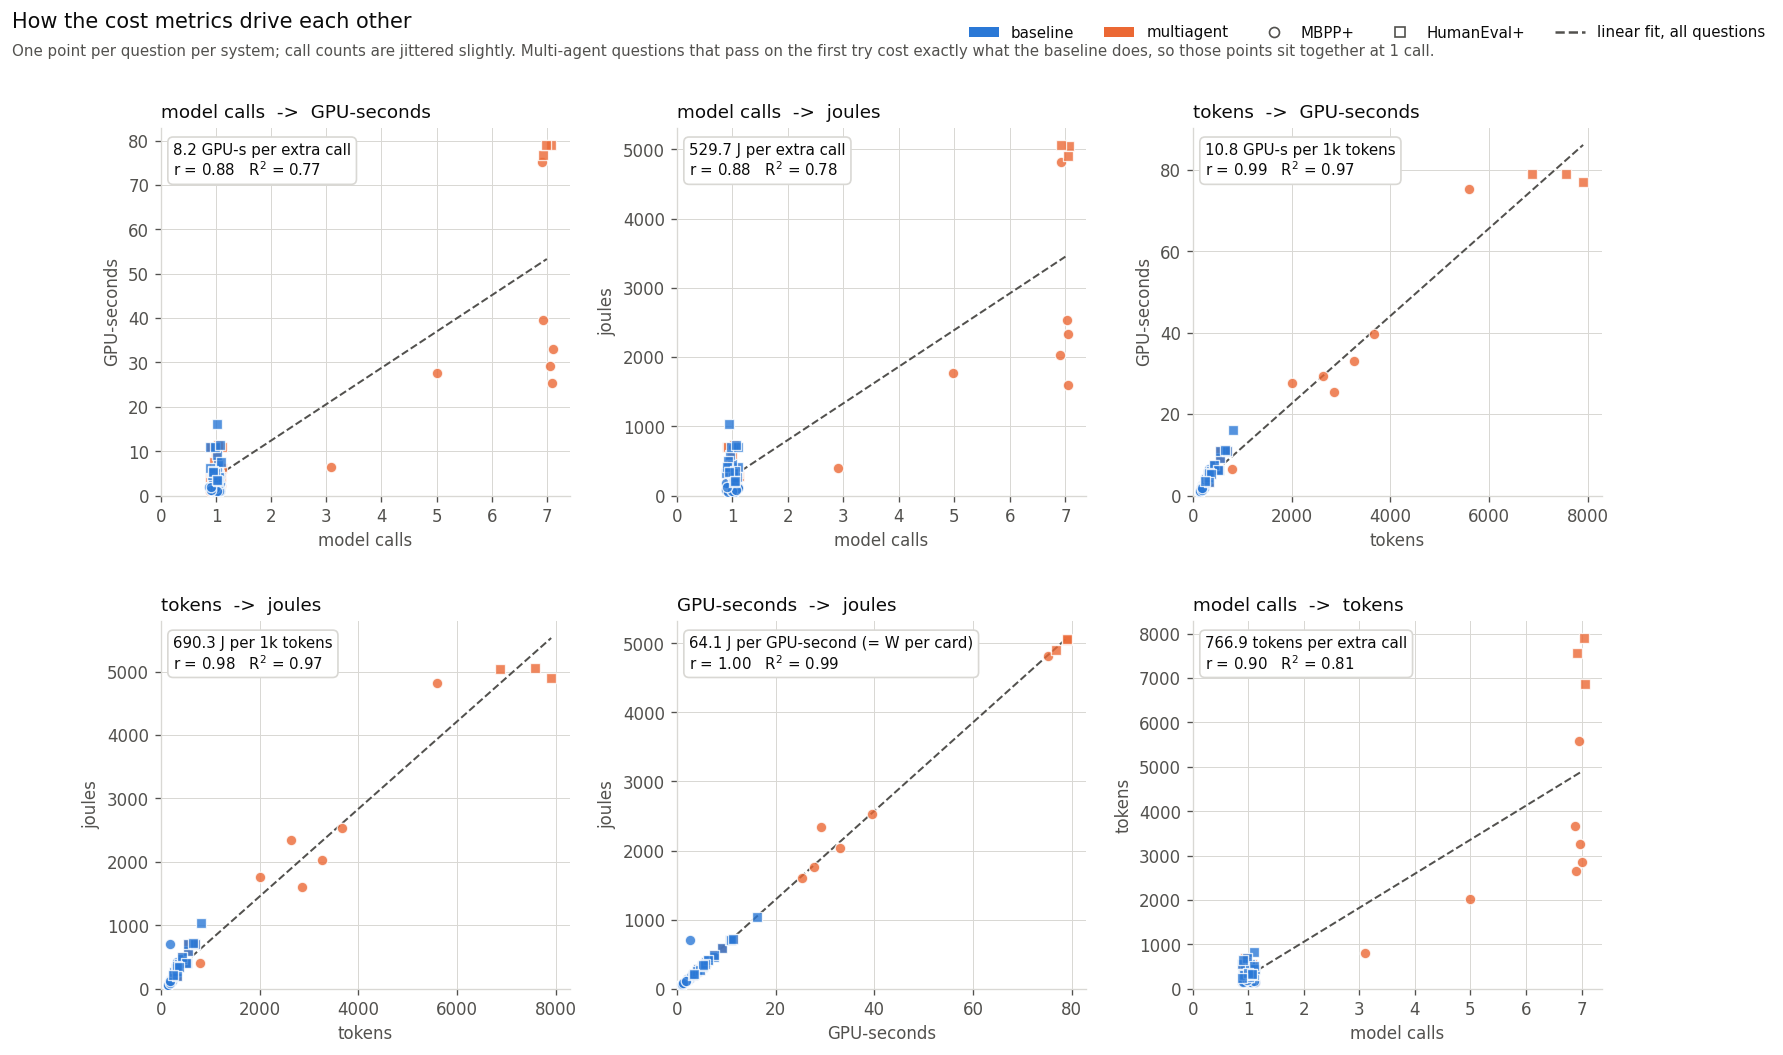

In [36]:
# --- Figure 8 : metric vs metric, one point per question --------------------
rng_j = np.random.default_rng(SEED)
MK = {M1_RESULTS[t]["label"]: ["o", "s", "^", "D"][i % 4] for i, t in enumerate(BENCH_TAGS)}

fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.2))
for ax, (x, y, xl, yl, mult, unit) in zip(axes.ravel(), PAIRS):
    for m in ["multiagent", "baseline"]:      # baseline last so it stays visible
        for bl, mk in MK.items():
            sub = TASKS_LONG[(TASKS_LONG.system == m) & (TASKS_LONG.benchmark == bl)]
            xv = sub[x].to_numpy(float)
            if x == "model_calls":        # small jitter so stacked integer points show
                xv = xv + rng_j.uniform(-0.12, 0.12, len(xv))
            ax.scatter(xv, sub[y], s=40, marker=mk, color=METHOD_COLOR[m], alpha=0.8,
                       edgecolor="white", linewidth=0.8, zorder=3)
    f = fit_line(TASKS_LONG[x], TASKS_LONG[y])
    if f["slope"] == f["slope"]:
        xs = np.linspace(np.nanmin(TASKS_LONG[x]), np.nanmax(TASKS_LONG[x]), 50)
        ax.plot(xs, f["intercept"] + f["slope"] * xs, "--", color=INK_2, linewidth=1.2, zorder=2)
        ax.text(0.03, 0.96, "%.1f %s\nr = %.2f   R$^2$ = %.2f"
                % (f["slope"] * mult, unit, f["r"], f["r2"]),
                transform=ax.transAxes, ha="left", va="top", fontsize=9, color=INK,
                bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=GRID))
    else:
        ax.text(0.5, 0.5, "no data (energy needs NVML)", transform=ax.transAxes,
                ha="center", va="center", color=INK_2)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title("%s  ->  %s" % (xl, yl), color=INK, loc="left")
    ax.set_xlim(left=0); ax.set_ylim(bottom=0)

handles = METHOD_HANDLES + [plt.Line2D([], [], marker=mk, color=INK_2, linestyle="none",
                                       markerfacecolor="none", label=bl)
                            for bl, mk in MK.items()]
handles.append(plt.Line2D([], [], linestyle="--", color=INK_2, label="linear fit, all questions"))
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(0.995, 0.995), ncol=5, fontsize=9)
fig.suptitle("How the cost metrics drive each other", x=0.045, ha="left",
             fontsize=12.5, color=INK, y=0.995)
fig.text(0.045, 0.955, "One point per question per system; call counts are jittered slightly. "
         "Multi-agent questions that pass on the first try cost exactly what the baseline "
         "does, so those points sit together at 1 call.", ha="left", fontsize=9, color=INK_2)
fig.subplots_adjust(top=0.89, hspace=0.34, wspace=0.26)
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_8_metric_relationships.png"))
plt.show()

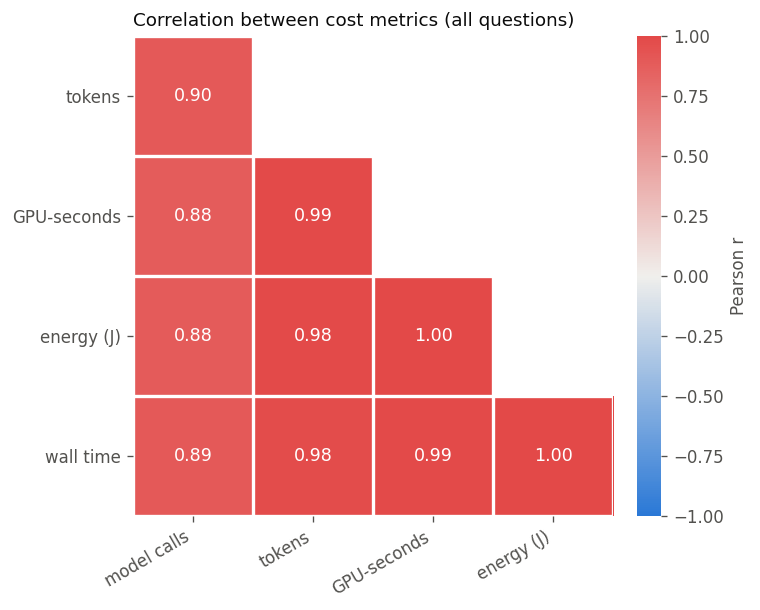

In [37]:
# --- Figure 9 : correlation matrix ------------------------------------------
from matplotlib.colors import LinearSegmentedColormap

VARS = [("model_calls", "model calls"), ("tokens", "tokens"),
        ("gpu_seconds", "GPU-seconds"), ("joules", "energy (J)"),
        ("wall_seconds", "wall time")]
cols = [v for v, _ in VARS if TASKS_LONG[v].notna().any()]
labs = [l for v, l in VARS if v in cols]
CORR = TASKS_LONG[cols].corr(method="pearson")
CORR.to_csv(os.path.join(M1_OUTPUT_DIR, "correlation_matrix.csv"))

# diverging: blue (negative) - gray (none) - red (positive)
div = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
# lower triangle only: the upper half repeats it, the diagonal is always 1
k = len(labs)
vals = CORR.values.copy()
mask = np.triu(np.ones((k, k), dtype=bool))
shown = np.ma.array(vals, mask=mask)[1:, :-1]
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(shown, cmap=div, vmin=-1, vmax=1)
ax.set_xticks(range(k - 1)); ax.set_xticklabels(labs[:-1], rotation=30, ha="right")
ax.set_yticks(range(k - 1)); ax.set_yticklabels(labs[1:])
ax.grid(False)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.set_xticks(np.arange(-0.5, k - 1, 1), minor=True)
ax.set_yticks(np.arange(-0.5, k - 1, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)      # surface gap between cells
ax.tick_params(which="minor", length=0)
for i in range(1, k):
    for j in range(i):
        v = vals[i, j]
        ax.text(j, i - 1, "%.2f" % v, ha="center", va="center", fontsize=10.5,
                color="white" if abs(v) > 0.6 else INK)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Pearson r", color=INK_2); cb.outline.set_visible(False)
ax.set_title("Correlation between cost metrics (all questions)", color=INK, loc="left")
fig.savefig(os.path.join(M1_OUTPUT_DIR, "fig_9_correlation_matrix.png"))
plt.show()

## 23 · Summary report

In [38]:
_idle = M1_CONFIG["IDLE_WATTS"]
L = ["# Milestone 1 results - %s" % MODEL_NAME, "",
     "%s - %d GPU(s) - idle %s - %s questions per benchmark" % (
         time.strftime("%Y-%m-%d %H:%M"), M1_CONFIG["N_GPUS"],
         ("%.1f W" % _idle) if _idle == _idle else "n/a",
         "all" if M1_N_PROBLEMS is None else M1_N_PROBLEMS), "",
     "## Correctness and cost per question", "",
     "| benchmark | system | n | pass@1 | calls | GPU-s | J | J above idle | tokens | GPU-s per solved |",
     "|---|---|---|---|---|---|---|---|---|---|"]
for r in M1_METRICS.to_dict("records"):
    L.append("| %s | %s | %d | %.1f | %.2f | %.1f | %.0f | %.0f | %.0f | %.1f |"
             % (r["benchmark"], r["method"], r["n_tasks"], r["pass@1"], r["calls_per_task"],
                r["gpu_s_per_task"], r["joules_per_task"], r["joules_above_idle_per_task"],
                r["tokens_per_task"], r["gpu_s_per_solved"]))

L += ["", "## Average model calls per question", "",
      "| benchmark | system | avg | generator | supervisor | repair | test writer | entered repair |",
      "|---|---|---|---|---|---|---|---|"]
for r in CALLS_TABLE.to_dict("records"):
    L.append("| %s | %s | %.2f | %.2f | %.2f | %.2f | %.2f | %s |"
             % (r["benchmark"], r["system"], r["avg_calls_per_question"],
                r["avg_generator_calls"], r["avg_supervisor_calls"], r["avg_repair_calls"],
                r["avg_test_writer_calls"],
                ("%d / %d" % (r["questions_entering_repair"], r["questions"]))
                if r["system"] == "multiagent" else "-"))

L += ["", "## Multi-agent cost by agent (per question)", "",
      "| benchmark | agent | calls | tokens | GPU-s | J | J above idle | share of GPU-s | share of energy |",
      "|---|---|---|---|---|---|---|---|---|"]
for r in AGENT_TABLE.to_dict("records"):
    if r["role"] == "executor":
        L.append("| %s | %s | %.2f | - | - | - | - | CPU: %.2f s/question | - |"
                 % (r["benchmark"], r["agent"], r["calls_per_question"],
                    r["wall_seconds"] / r["questions"]))
    elif r["calls"]:
        L.append("| %s | %s | %.2f | %.0f | %.2f | %.0f | %.0f | %.0f%% | %.0f%% |"
                 % (r["benchmark"], r["agent"], r["calls_per_question"],
                    r["tokens_per_question"], r["gpu_s_per_question"],
                    r["joules_per_question"], r["joules_above_idle_per_question"],
                    r["share_gpu_s_%"], r["share_energy_%"]))

L += ["", "## Paired comparison", "",
      "| benchmark | n | delta (pp) | gains | regressions | p (exact McNemar) | do-no-harm | n>=45 |",
      "|---|---|---|---|---|---|---|---|"]
for r in M1_STATS.to_dict("records"):
    L.append("| %s | %d | %+.1f | %d | %d | %.4f | %s | %s |"
             % (r["benchmark"], r["n"], r["delta_pp"], r["b01_gains"], r["b10_regressions"],
                r["p_exact"], "pass" if r["do_no_harm_pass"] else "FAIL",
                "yes" if r["powered_n45"] else "no"))

L += ["", "## How the metrics relate (linear fit, one point per question)", "",
      "| scope | from | to | marginal rate | r | R^2 |", "|---|---|---|---|---|---|"]
for r in RELATIONS.to_dict("records"):
    L.append("| %s | %s | %s | %.2f %s | %.2f | %.2f |"
             % (r["scope"], r["x"], r["y"], r["rate"], r["rate_unit"],
                r["pearson_r"], r["r_squared"]))

SUMMARY_MD = "\n".join(L)
with open(os.path.join(M1_OUTPUT_DIR, "summary.md"), "w") as f:
    f.write(SUMMARY_MD)
print(SUMMARY_MD)

# Milestone 1 results - qwen3-coder:30b

2026-09-20 12:14 - 2 GPU(s) - idle 54.9 W - 20 questions per benchmark

## Correctness and cost per question

| benchmark | system | n | pass@1 | calls | GPU-s | J | J above idle | tokens | GPU-s per solved |
|---|---|---|---|---|---|---|---|---|---|
| MBPP+ | baseline | 20 | 65.0 | 1.00 | 2.0 | 152 | 96 | 186 | 3.1 |
| MBPP+ | multiagent | 20 | 80.0 | 2.80 | 12.8 | 833 | 481 | 1148 | 16.0 |
| HumanEval+ | baseline | 20 | 85.0 | 1.00 | 6.9 | 440 | 250 | 432 | 8.1 |
| HumanEval+ | multiagent | 20 | 85.0 | 1.90 | 17.2 | 1096 | 624 | 1461 | 20.2 |

## Average model calls per question

| benchmark | system | avg | generator | supervisor | repair | test writer | entered repair |
|---|---|---|---|---|---|---|---|
| MBPP+ | baseline | 1.00 | 1.00 | 0.00 | 0.00 | 0.00 | - |
| MBPP+ | multiagent | 2.80 | 1.00 | 0.90 | 0.90 | 0.00 | 7 / 20 |
| HumanEval+ | baseline | 1.00 | 1.00 | 0.00 | 0.00 | 0.00 | - |
| HumanEval+ | multiagent | 1.90 | 1.00 | 0.45 | 0

## 24 · Download all results

This last cell zips everything in `outputs_milestone1/` — CSVs, per-call logs, figures and the
summary — into **`milestone1_results.zip`**.

- **Kaggle:** click the link printed below, or open the **Output** panel on the right. Files in
  `/kaggle/working` are deleted when the session ends unless you download them or press
  *Save Version*.
- **Colab:** the download starts automatically.

In [39]:
import zipfile

ZIP_PATH = os.path.join(BASE_DIR, "milestone1_results.zip")
n_files = 0
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(M1_OUTPUT_DIR):
        for fn in sorted(files):
            full = os.path.join(root, fn)
            z.write(full, os.path.relpath(full, BASE_DIR))
            n_files += 1

print("Packed %d files -> %s  (%.1f MB)"
      % (n_files, os.path.abspath(ZIP_PATH), os.path.getsize(ZIP_PATH) / 1e6))
with zipfile.ZipFile(ZIP_PATH) as z:
    for name in z.namelist():
        print("   ", name)

if globals().get("IS_COLAB"):
    from google.colab import files
    files.download(ZIP_PATH)
else:
    try:
        from IPython.display import FileLink, display
        print("\nClick to download:")
        display(FileLink(os.path.relpath(ZIP_PATH)))
    except Exception:
        print("\nDownload it from:", os.path.abspath(ZIP_PATH))
    if ON_KAGGLE:
        print("On Kaggle it is also listed in the Output panel (right sidebar) -> milestone1_results.zip")

Packed 26 files -> /kaggle/working/milestone1_results.zip  (1.4 MB)
    outputs_milestone1/calls_per_question.csv
    outputs_milestone1/correlation_matrix.csv
    outputs_milestone1/fig_10_cost_by_agent.png
    outputs_milestone1/fig_11_cost_per_call_by_agent.png
    outputs_milestone1/fig_1_pass_at_1.png
    outputs_milestone1/fig_2_cost_axes.png
    outputs_milestone1/fig_3_calls_by_role.png
    outputs_milestone1/fig_4_efficiency.png
    outputs_milestone1/fig_5_frontier.png
    outputs_milestone1/fig_6_paired_outcomes.png
    outputs_milestone1/fig_7_calls_per_question.png
    outputs_milestone1/fig_8_metric_relationships.png
    outputs_milestone1/fig_9_correlation_matrix.png
    outputs_milestone1/metric_relationships.csv
    outputs_milestone1/metrics.csv
    outputs_milestone1/ollama_serve.log
    outputs_milestone1/per_agent_costs.csv
    outputs_milestone1/per_question_costs.csv
    outputs_milestone1/stats.csv
    outputs_milestone1/summary.md
    outputs_milestone1/humanev

/kaggle/working/milestone1_results.zip

On Kaggle it is also listed in the Output panel (right sidebar) -> milestone1_results.zip


---
### Measurement notes
- **GPU-seconds are occupancy**, not utilisation: call duration × GPUs holding the model.
- **Energy is GPU-card energy** from NVML. CPU, RAM and PSU losses are excluded, so it is a lower
  bound on machine energy — but it is measured identically for both systems.
- **Sandbox execution is CPU work** and is not part of GPU-seconds or joules.
- **n = 20 is a smoke test.** McNemar needs n ≥ 45 per benchmark before a p-value is meaningful;
  set `M1_N_PROBLEMS = None` for the full benchmarks.